# Minería de Datos

---
## Taller: Preprocesamiento

---
**Profesora:** Elizabeth León Guzmán

Este notebook contiene las actividades del taller de preprocesamiento. Cada sección incluye espacios para implementar los cálculos o experimentos en Python o documentar los resultados.

---

**Estudiante:** Nicolás Martínez López

**Universidad Nacional de Colombia**

**Sede Bogotá**

---

## Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from scipy.stats import zscore
import random
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

## **1. Normalización**
Dado el conjunto de datos:

X = {-5.0, 23.0, 17.6, 7.23, 1.11}

Realizar:
- Min-Max normalización en [0,1]
- Min-Max normalización en [-1,1]
- Normalización usando desviación estándar
- Escala decimal
- Comparar resultados

In [ ]:
X = np.array([-5.0, 23.0, 17.6, 7.23, 1.11])

# Min-Max [0,1]
X_min = X.min()
X_max = X.max()
X_norm_Min_Max = (X - X_min) / (X_max - X_min)

# Min-Max [-1,1]
X_norm_Min_Max_1 = -1 + 2*((X - X_min) / (X_max - X_min))

# Desviación estándar
X_mean = X.mean()
X_std = X.std()
X_norm_std = (X - X_mean) / X_std

# Escala decimal
X_dec_max = np.ceil(np.log10(np.max(np.abs(X))))
X_norm_dec = X / 10**X_dec_max

# Comparación
df_comparison = pd.DataFrame({
    'Original X': X,
    'Min-Max [0,1]': X_norm_Min_Max,
    'Min-Max [-1,1]': X_norm_Min_Max_1,
    'Standardization': X_norm_std,
    'Decimal Scaling': X_norm_dec
})

print(f'X with Min-Max normalization in [0,1]: {X_norm_Min_Max}')
print(f'X with Min-Max normalization in [-1,1]: {X_norm_Min_Max_1}')
print(f'X with standardization: {X_norm_std}')
print(f'X with decimal scaling: {X_norm_dec}')
print('\nComparison Table:')
display(df_comparison)

X with Min-Max normalization in [0,1]: [0.         1.         0.80714286 0.43678571 0.21821429]
X with Min-Max normalization in [-1,1]: [-1.          1.          0.61428571 -0.12642857 -0.56357143]
X with standardization: [-1.33779582  1.37893488  0.85499396 -0.15116666 -0.74496637]
X with decimal scaling: [-0.05    0.23    0.176   0.0723  0.0111]

Comparison Table:


,Original X,"Min-Max [0,1]","Min-Max [-1,1]",Standardization,Decimal Scaling
0,-5.00,0.000000,-1.000000,-1.337796,-0.0500
1,23.00,1.000000,1.000000,1.378935,0.2300
2,17.60,0.807143,0.614286,0.854994,0.1760
3,7.23,0.436786,-0.126429,-0.151167,0.0723
4,1.11,0.218214,-0.563571,-0.744966,0.0111


## **2. Valores perdidos**
**2.1
Dataset:**

| I1 | I2 | I3 | I4 |
|----|----|----|----|
|0|1|1|2|
|2|1|?|1|
|1|?|?|0|
|?|2|1|?|
|2|2|1|0|

- Dominio: {0,1,2}
- Calcular número de ejemplos artificiales si los valores faltantes se reemplazan con todos los posibles valores.
- Proponer otro método para imputación.

In [ ]:
dataset = pd.DataFrame({
    'I1': [0, 2, 1, np.nan, 2],
    'I2': [1, 1, np.nan, 2, 2],
    'I3': [1, np.nan, np.nan, 1, 1],
    'I4': [2, 1, 0, np.nan, 0]
})

domain = [0, 1, 2]

print('Dataset:')
display(dataset)
print('Domain:', domain)

Dataset:


,I1,I2,I3,I4
0,0.0,1.0,1.0,2.0
1,2.0,1.0,NaN,1.0
2,1.0,NaN,NaN,0.0
3,NaN,2.0,1.0,NaN
4,2.0,2.0,1.0,0.0


Domain: [0, 1, 2]


In [ ]:
def calculate_number_of_artificial_examples(dataset, domain):
  examples = 0
  for index, row in dataset.iterrows():
    missing_values = 0
    for col_name, value in row.items():
      if pd.isna(value):
        missing_values += 1
    if missing_values > 0:
      examples += len(domain) ** missing_values

  return examples

In [ ]:
print(f'Number of Artificial Examples for the Dataset: {calculate_number_of_artificial_examples(dataset, domain)}')

Number of Artificial Examples for the Dataset: 21


Additional Proposed Imputation Method: **Mode Imputation**

This choice is justified because the variables in the dataset take **discrete and limited values (0, 1, and 2)**, which suggests that they behave more like **categorical or ordinal attributes** rather than continuous numerical variables. Using statistical measures such as the mean could generate values that **do not exist in the original domain of the data**, which would reduce the interpretability of the dataset.

Additionally, the dataset is **very small**, containing only five observations. In such cases, more complex methods such as regression or K-nearest neighbors imputation may introduce unnecessary complexity and unstable estimates due to the limited amount of data.

Mode imputation is therefore appropriate because it:
- **Preserves the discrete nature of the attributes**
- **Maintains values within the original domain**
- **Is simple and robust for small datasets**

For these reasons, replacing missing values with the **most frequent value (mode) of each attribute** provides a consistent and interpretable solution for this dataset.

In [ ]:
def mode_imputation(dataset, columns):
  imputed_dataset = dataset.copy()
  for col in columns:
    mode = imputed_dataset[col].mode()[0]
    imputed_dataset[col] = imputed_dataset[col].fillna(mode)
  return imputed_dataset

In [ ]:
print('Original Dataset:')
display(dataset)
print('\nImputed Dataset with Mode:')
imputed_dataset = mode_imputation(dataset, ['I1', 'I2', 'I3', 'I4'])
display(mode_imputation(dataset, imputed_dataset))

Original Dataset:


,I1,I2,I3,I4
0,0.0,1.0,1.0,2.0
1,2.0,1.0,NaN,1.0
2,1.0,NaN,NaN,0.0
3,NaN,2.0,1.0,NaN
4,2.0,2.0,1.0,0.0



Imputed Dataset with Mode:


,I1,I2,I3,I4
0,0.0,1.0,1.0,2.0
1,2.0,1.0,1.0,1.0
2,1.0,1.0,1.0,0.0
3,2.0,2.0,1.0,0.0
4,2.0,2.0,1.0,0.0


 **2.2 Cargar el conjunto de datos de cancer que se encuentra en: (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original). Los valores perdidos están identificados con  '?'**


*   Imprimir Numero de instancias, número de atributos, y nombre y número de valores perdidos por cada uno de los atributos. ¿Qué sucede con la variable 'Bare Nuclei'?
*   Remplazar los valores perdidos de la variable 'Bare Nuclei' con el valor de la media.
* Otro método de tratar valores perdido es eliminar los objetos que tienen valores perdidos. Borrar los objetos que tienen valores perdidos e imprimir el tamaño del nuevo conjunto de datos. ¿Cuál fue la proporción de ejemplos borrados?




Load Dataset

In [ ]:
cancer_df = pd.read_csv('breast-cancer-wisconsin.data', header=None)

In [ ]:
## Add Column Names
column_names = [
    'Sample_code_number', 'Clump_Thickness', 'Uniformity_of_Cell_Size', 'Uniformity_of_Cell_Shape',
    'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei',
    'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class'
]
cancer_df.columns = column_names
display(cancer_df.head())

,Sample_code_number,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Print Number of Instances, Number of Attributes, Name and Number of Missing Values of Each Attribute

In [ ]:
# Replace '?' with NaN
cancer_df = cancer_df.replace('?', np.nan)

# Convert columns to numeric, coercing errors will turn non-numeric (like '?' now nan) to NaN
# Exclude 'Sample code number' and 'Class' if they are not meant to be purely numeric features.
for col in cancer_df.columns:
    if col not in ['Sample_code_number', 'Class']:
        cancer_df[col] = pd.to_numeric(cancer_df[col], errors='coerce')

# Number of instances
num_instances = cancer_df.shape[0]

# Number of attributes
num_attributes = cancer_df.shape[1]

# Name and number of missing values for each attribute
missing_values_count = cancer_df.isnull().sum()

print(f"Number of instances: {num_instances}")
print(f"Number of attributes: {num_attributes}")
print("\nMissing values per attribute:")
print(missing_values_count[missing_values_count > 0])

Number of instances: 699
Number of attributes: 11

Missing values per attribute:
Bare_nuclei    16
dtype: int64


The Bare_nuclei variable is the only one that contains missing values, specifically 16 records.

**Replace Missing Values of Bare_nuclei attribute with the value of its average**

In [ ]:
cancer_df_fixed_with_average = cancer_df.copy()
print(f'Missing Values of Bare_nuclei attribute: {cancer_df_fixed_with_average['Bare_nuclei'].isnull().sum()}')
mean_bare_nuclei = cancer_df_fixed_with_average['Bare_nuclei'].mean()
print(f'Bare_nuclei Average: {mean_bare_nuclei}')
cancer_df_fixed_with_average['Bare_nuclei'] = cancer_df_fixed_with_average['Bare_nuclei'].fillna(mean_bare_nuclei)

print("DataFrame after imputing 'Bare_nuclei' with its mean:")
display(cancer_df_fixed_with_average.head())
print(f'Missing Values of Bare_nuclei attribute: {cancer_df_fixed_with_average['Bare_nuclei'].isnull().sum()}')

Missing Values of Bare_nuclei attribute: 16
Bare_nuclei Average: 3.5446559297218156
DataFrame after imputing 'Bare_nuclei' with its mean:


,Sample_code_number,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


Missing Values of Bare_nuclei attribute: 0


Another Method to solve missing values: Delete Objects with Missing Values

In [ ]:
def delete_objects_with_missing_values(df):
  df_copy = df.copy()
  df_copy.dropna(inplace=True)
  return df_copy

In [ ]:
cancer_df_delete_objects = delete_objects_with_missing_values(cancer_df)

In [ ]:
print(f'Initial Number of Objects: {num_instances}')
print(f'Dataset after Deleting Objects with Missing Values: {cancer_df_delete_objects.shape[0]}')

Initial Number of Objects: 699
Dataset after Deleting Objects with Missing Values: 683


## **3. Detección de Outliers**


### **1.**
Vector:
C = {3, 1, 0, 2, 7, 3, 6, 4, -2, 0, 0, 10, 15, 6}

- Calcular media
- Calcular desviación estándar
- Detectar outliers usando ±3σ y ±2σ

In [ ]:
C = np.array([3,1,0,2,7,3,6,4,-2,0,0,10,15,6])

mean = C.mean()
std = C.std()

In [ ]:
def outliers_std(C, std):
    print(f"Calculating outliers with +- {std} standard deviation...")
    outliers = []
    mean = np.mean(C)
    std_dev = np.std(C)
    print(f"Mean: {mean}, Standard Deviation: {std_dev}")
    for value in C:
        if abs(value - mean) > std * std_dev:
            #print(f"    Value {value} is an outlier ({abs(value - mean)} > {std* std_dev})")
            outliers.append(value) # Convert to standard Python int
        else:
          continue
          #print(f"    Value {value} isn't an outlier ({abs(value - mean)} <= {std* std_dev})")
    return np.array(outliers)

In [ ]:
print('Outliers with +- 3 standard deviation:')
outliers_3_std = outliers_std(C, 3)
print(f'Were found {len(outliers_3_std)} outliers: {outliers_3_std}')

print('\nOutliers with +- 2 standard deviation:')
outliers_2_std = outliers_std(C, 2)
print(f'Were found {len(outliers_2_std)} outliers: {outliers_2_std}')

Outliers with +- 3 standard deviation:
Calculating outliers with +- 3 standard deviation...
Mean: 3.9285714285714284, Standard Deviation: 4.4153027030073115
Were found 0 outliers: []

Outliers with +- 2 standard deviation:
Calculating outliers with +- 2 standard deviation...
Mean: 3.9285714285714284, Standard Deviation: 4.4153027030073115
Were found 1 outliers: [15]


### **2.**

* Dibujar *boxplot*  para el conjunto de datos del ejercicio anterior (cancer)  
*   ¿Cuáles variables tienen valores
anormalmente altos?

*  Para eliminar outliers, computar  Z-score por cada atributo y remover las instancias que contengan atributos con valores anormalmente altos o con bajo Z-score (ejemplo, if Z > 3 or Z <= -3).
*   Elemento de la lista


**Cancer Dataset Boxplot**

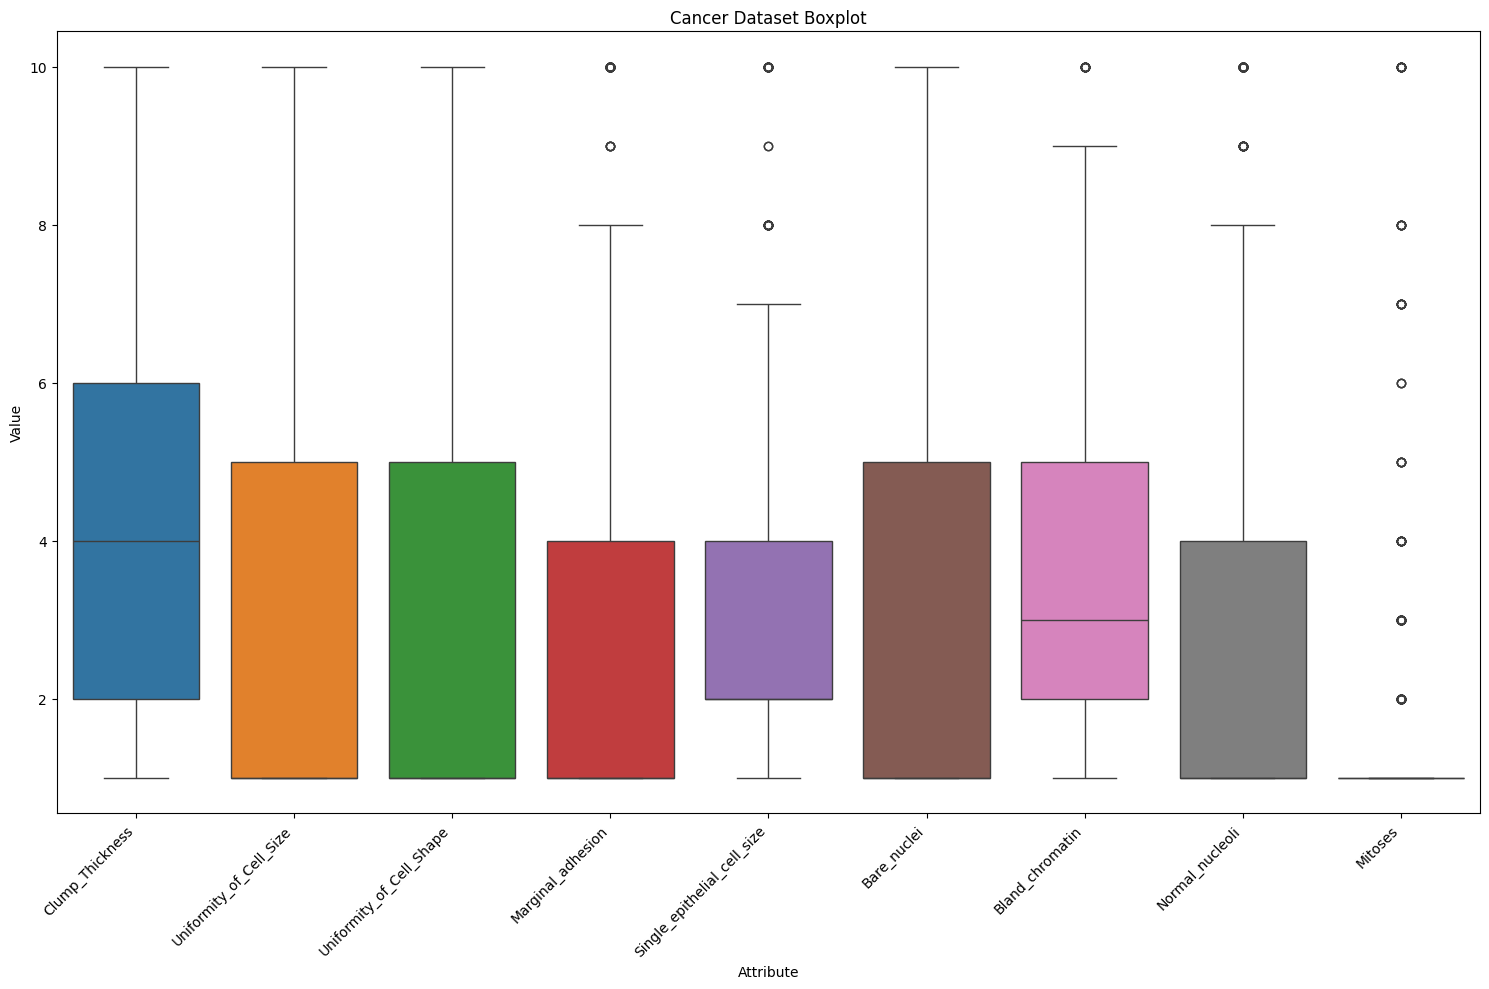

In [ ]:
# Identify numerical columns for boxplot, excluding 'Sample_code_number' and 'Class'
numerical_cols = cancer_df_fixed_with_average.columns.drop(['Sample_code_number', 'Class'])

plt.figure(figsize=(15, 10))
sns.boxplot(data=cancer_df_fixed_with_average[numerical_cols])
plt.title('Cancer Dataset Boxplot')
plt.ylabel('Value')
plt.xlabel('Attribute')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
cancer_df_fixed_with_average['Mitoses'].value_counts()

,count
Mitoses,
1,579
2,35
3,33
10,14
4,12
7,9
8,8
5,6
6,3


**Which variables have abnormally high values?**

The dataset variables that present abnormally high values are the following:

* Marginal Adhesion
* Single Epithelial Cell Size
* Bland Chromatin
* Normal Nucleoli
* **Mitoses:** This variable shows the most abnormal behavior because it contains a large number of values that appear far from the boxplot distribution. This occurs because 579 out of 699 observations have the value '1'.

**Delete Outliers with Z-Score**

In [ ]:
cancer_df_no_outliers = cancer_df_fixed_with_average.copy()
numerical_cols_for_zscore = cancer_df_no_outliers.columns.drop(['Sample_code_number', 'Class'])

# Calculate Z-scores for selected numerical columns
# Apply zscore row-wise (axis=0) to each column
z_scores = np.abs(zscore(cancer_df_no_outliers[numerical_cols_for_zscore]))
outlier_mask = (z_scores > 3).any(axis=1)

initial_num_instances = cancer_df_no_outliers.shape[0]
cancer_df_no_outliers = cancer_df_no_outliers[~outlier_mask]

# Get the number of instances after removing outliers
num_instances_after_removal = cancer_df_no_outliers.shape[0]
num_outliers_removed = initial_num_instances - num_instances_after_removal

print(f"Intial Number of Instances: {initial_num_instances}")
print(f"Number of outliers deleted (Z > 3 | Z < -3): {num_outliers_removed}")
print(f"Number of instances after deleting outliers: {num_instances_after_removal}")
#display(cancer_df_no_outliers.head())

Intial Number of Instances: 699
Number of outliers deleted (Z > 3 | Z < -3): 51
Number of instances after deleting outliers: 648


### **3.**

X = [(1,2,0),(3,1,4),(2,1,5),(0,1,6),(2,4,3),(4,4,2),(5,2,1),(7,7,7),(0,0,0),(3,3,3)]

Describir el procedimiento de detección de outliers usando media y varianza.

In [ ]:
X = [[1, 2, 0],
     [3, 1, 4],
     [2, 1, 5],
     [0, 1, 6],
     [2, 4, 3],
     [4, 4, 2],
     [5, 2, 1],
     [7, 7, 7],
     [0, 0, 0],
     [3, 3, 3]]

The following procedure detects outliers in a dataset by comparing each value with the **mean** of its attribute and evaluating whether it exceeds a threshold defined by a number of **standard deviations**.

***1. Iterate Through Each Attribute***

The algorithm evaluates the dataset **attribute by attribute** (column by column).  
For each attribute, the method analyzes all the values belonging to that dimension.

***2. Compute Statistical Measures***

For each attribute, the following statistics are calculated:

- **Mean (μ):** the average value of the attribute.
- **Variance (σ²):** measures the dispersion of the data relative to the mean.
- **Standard Deviation (σ):** the square root of the variance, representing the typical distance of values from the mean.

These statistics summarize the **central tendency and variability** of the data.

***3. Define the Outlier Threshold***

A threshold is defined using a parameter called `num_std`, which represents the number of **standard deviations allowed from the mean**.

The condition used is:

$|x - \mu| > k\sigma$

where:
- $X$ is the value being evaluated
- $\mu$ is the mean of the attribute
- $\sigma$ is the standard deviation
- $k$ is the number of standard deviations (in this case, $k = 2$)

This creates an acceptable interval:


$\mu - k\sigma, \mu + k\sigma$

Values outside this range are considered **potential outliers**.

***4. Evaluate Each Observation***
For each row in the dataset:

1. The absolute difference between the value and the mean is calculated.
2. If this difference is **greater than the threshold** $k\sigma$, the observation is marked as an **outlier for that attribute**.
3. The index of that observation is stored to avoid duplicates if the same row is detected as an outlier in multiple attributes.

***5. Store and Report Outliers***
All rows that satisfy the outlier condition are stored in a list of indices.  
Finally, the algorithm prints and returns the **rows that contain outlier values**

In [ ]:
def detect_outliers_mean_var(X, num_std = 2):
  index_outliers = []
  for att in range(len(X[0])):
    print(f'Evaluating Attribute {att+1} with {num_std} Standard Deviations')
    mean = np.mean([row[att] for row in X])
    std = np.std([row[att] for row in X])
    print(f'Attribute {att + 1}: Mean = {mean}, Variance = {std**2}, Standard Deviation = {std}')
    for index, row in enumerate(X):
      if index in index_outliers:
        continue
      if abs(row[att] - mean) > num_std * std:
        print(f'    → Row: {row} is an outlier because |{row[att]} - {mean}| = {abs(row[att] - mean)} > {num_std * std:}')
        if index not in index_outliers:
          index_outliers.append(index)
  return index_outliers

In [ ]:
outliers_X = detect_outliers_mean_var(X)
print('Outliers found:')
for idx in outliers_X:
    print(f'  {X[idx]}')

Evaluating Attribute 1 with 2 Standard Deviations
Attribute 1: Mean = 2.7, Variance = 4.41, Standard Deviation = 2.1
    → Row: [7, 7, 7] is an outlier because |7 - 2.7| = 4.3 > 4.2
Evaluating Attribute 2 with 2 Standard Deviations
Attribute 2: Mean = 2.5, Variance = 3.8500000000000005, Standard Deviation = 1.9621416870348585
Evaluating Attribute 3 with 2 Standard Deviations
Attribute 3: Mean = 3.1, Variance = 5.289999999999999, Standard Deviation = 2.3
Outliers found:
  [7, 7, 7]


## **5. Experimentos en Weka**
- Cargar dataset **iris**
- Eliminar 15% de valores
- Aplicar métodos de imputación
- Comparar resultados
- Normalizar atributos
- Discretizar atributos

### **Load Iris Dataset**

The next codeblocks will be used for getting a complete dataset with column names.

In [ ]:
# iris = pd.read_csv("./iris.data", names=["Sepal.Length","Sepal.Width" , "Petal.Length" ,"Petal.Width" , "Species"])
# iris

In [ ]:
# iris.to_csv("iris.csv", index=False)

Screenshot of Datatset loaded in Weka

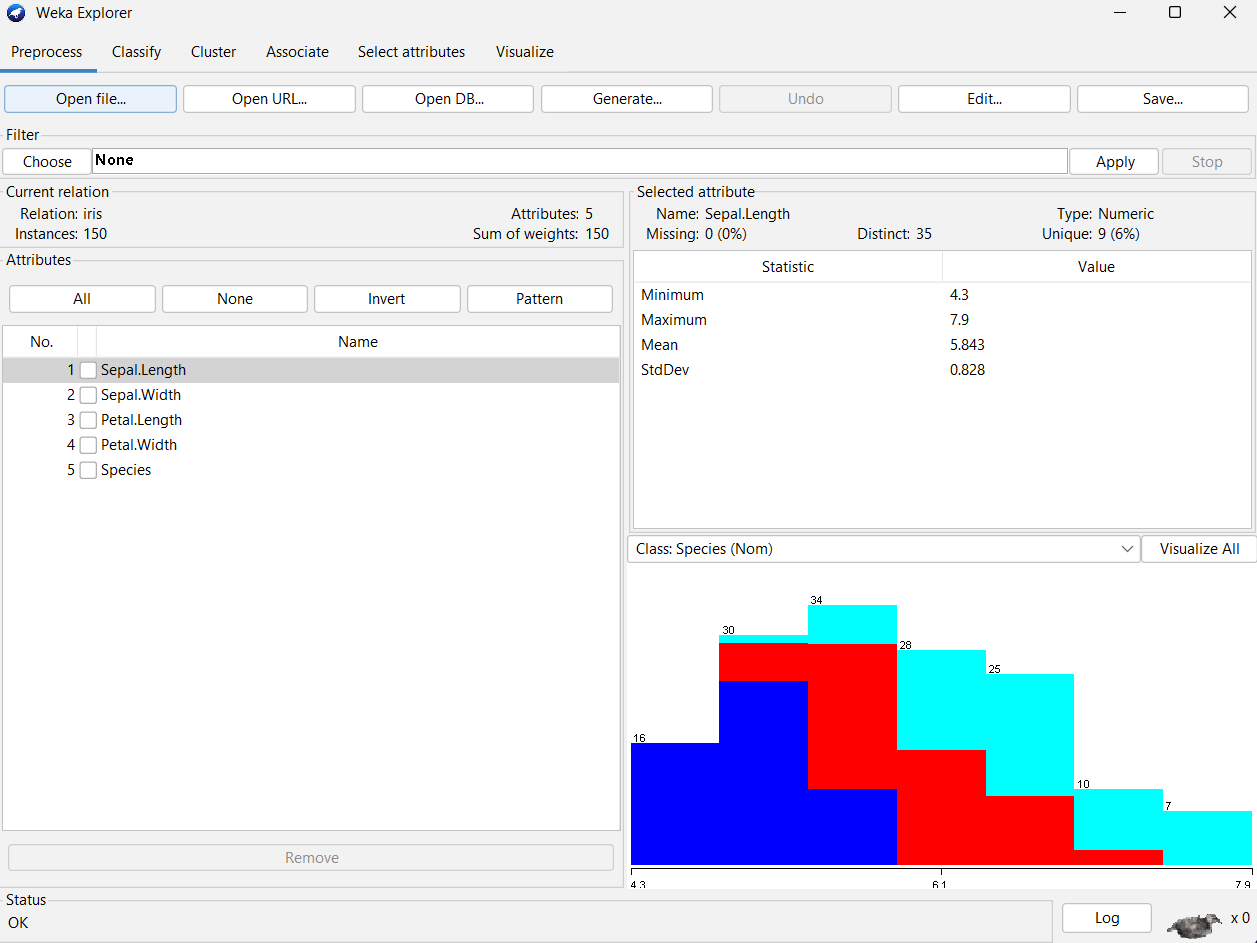

### **Delete 15% of Values**

Screenshot of filter used to introduce 15% of missing values in our dataset

We will use the filter ReplaceWithMissingValue, with a probability of 15% for the 5 attributes.

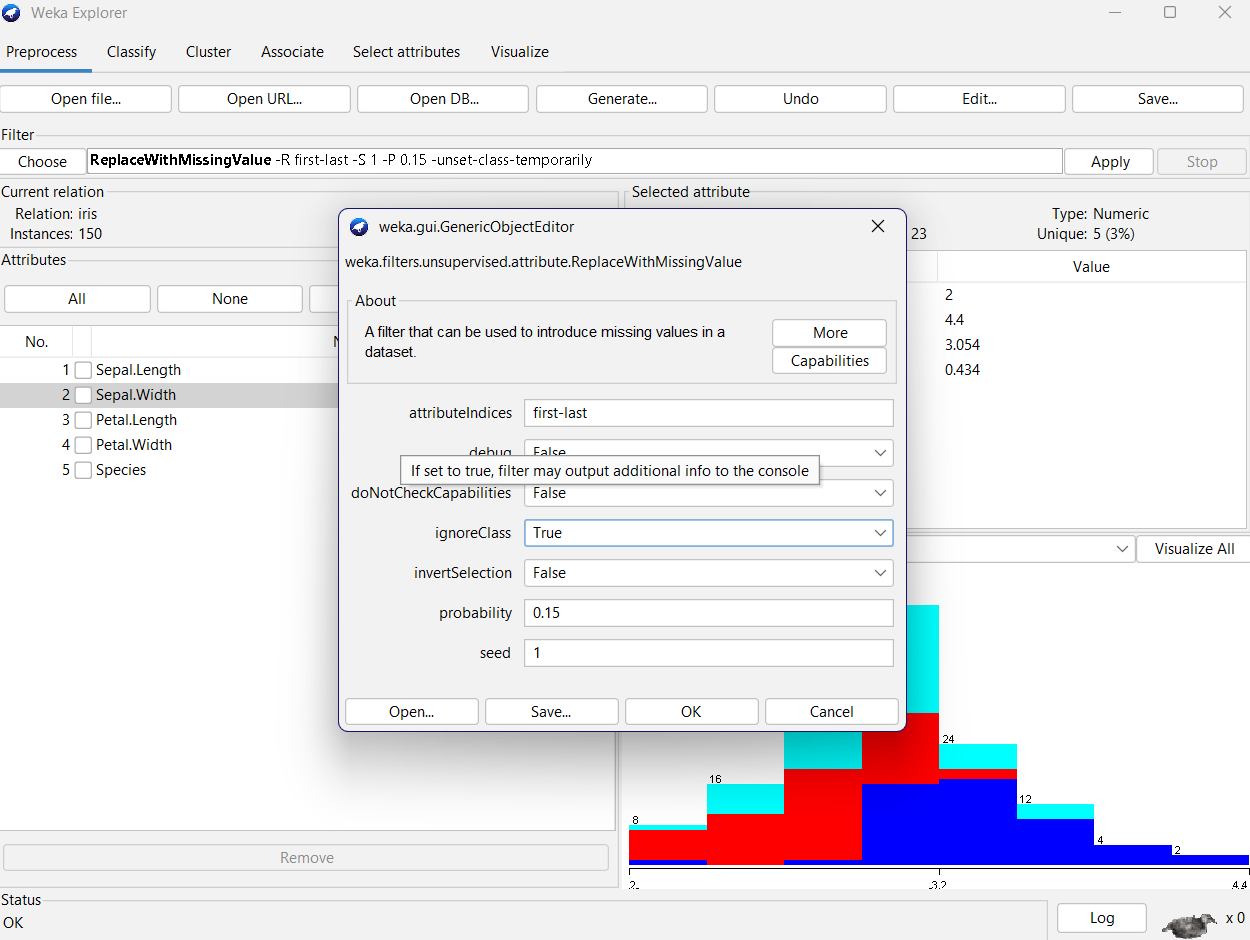

Filter applied

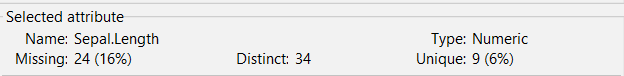
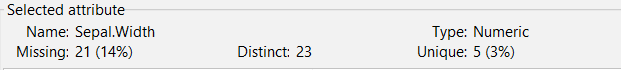
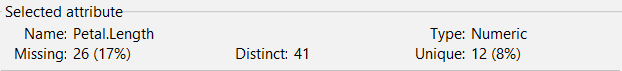
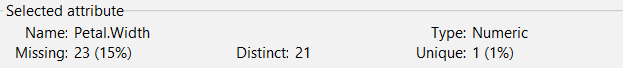
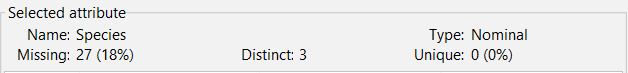

New Dataset Screenshot

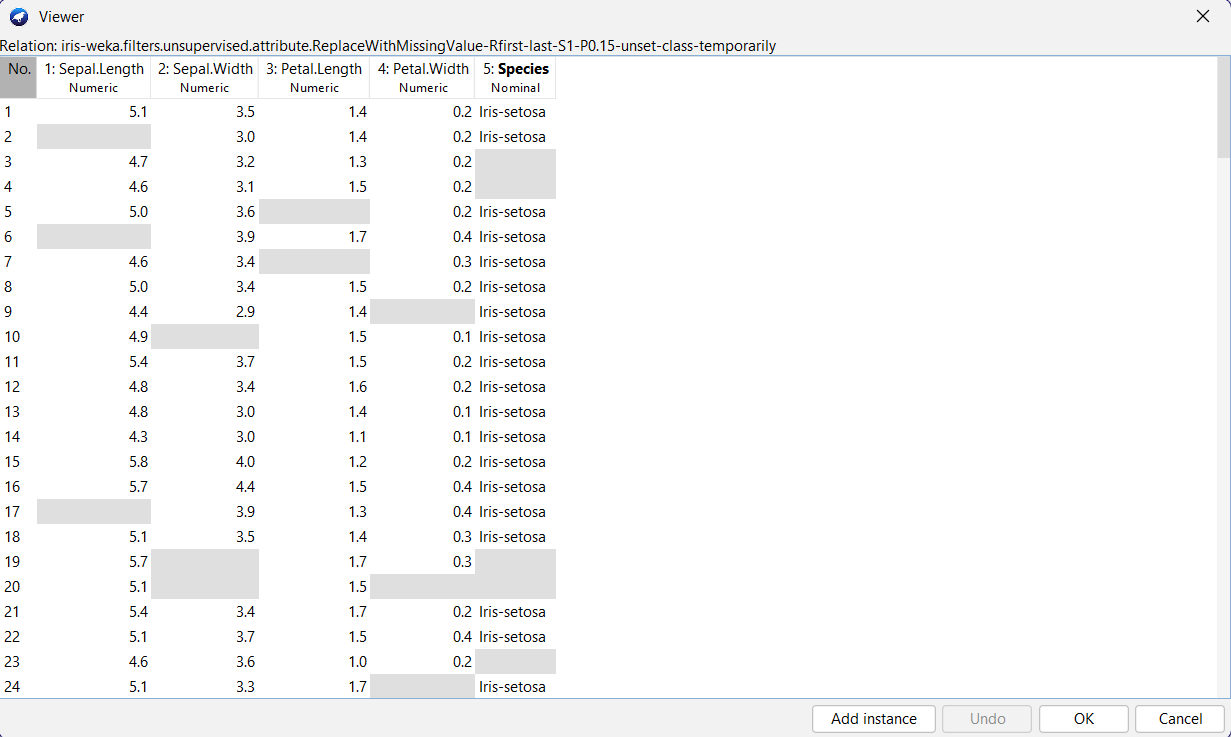

### **Apply Imputation Methods**

We will use ReplaceMissingValuesFilter which replaces numeric values with the mean and nominal values with the mode.

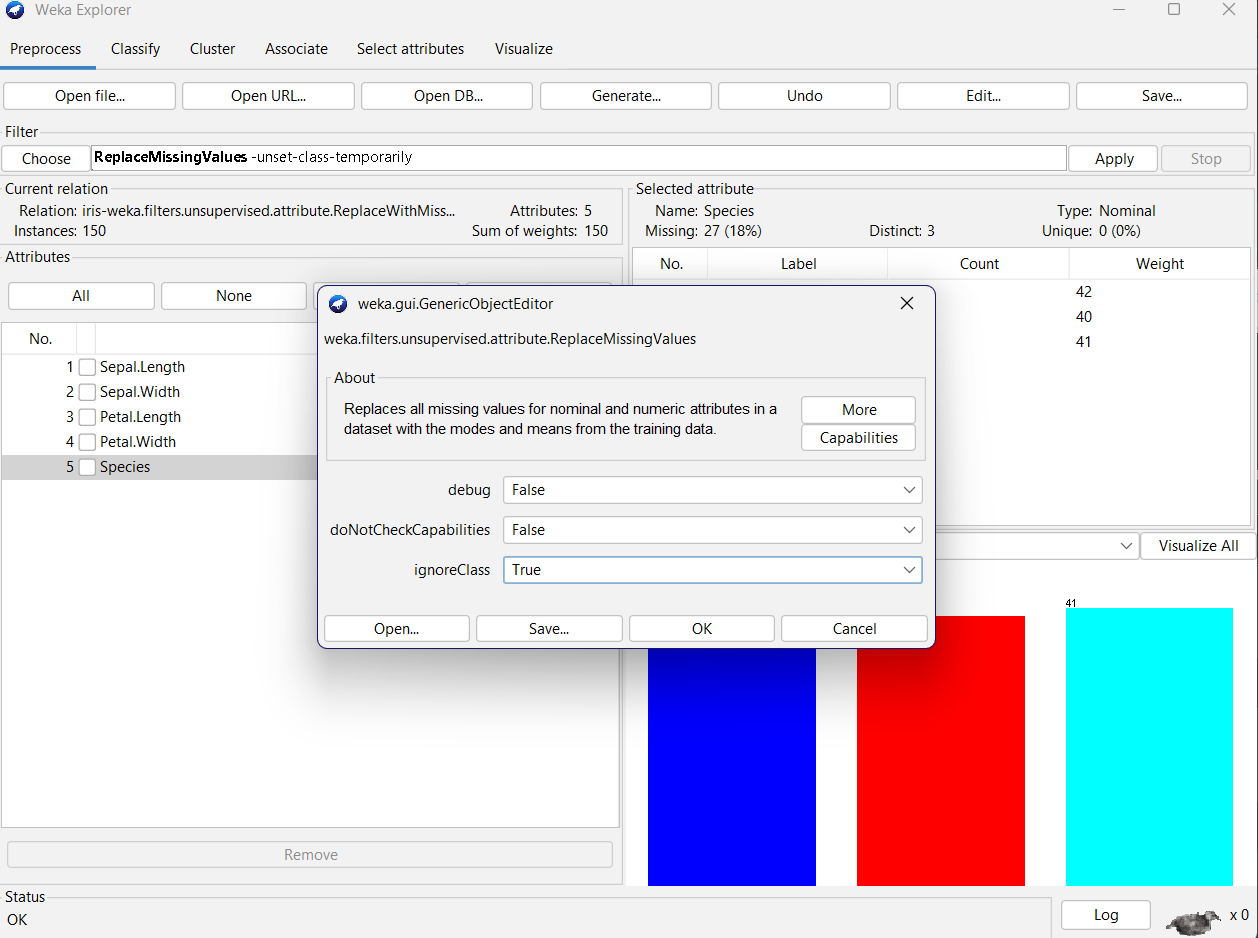

The Imputation-Filled columns result is the following one

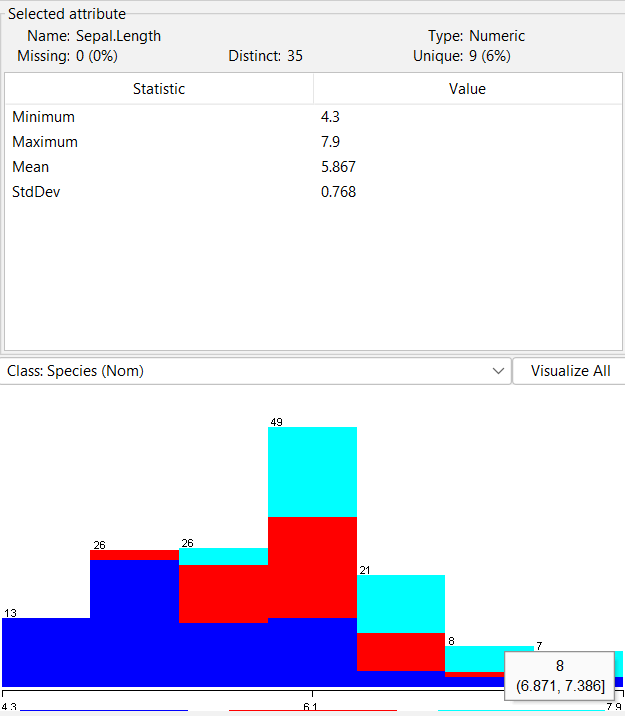

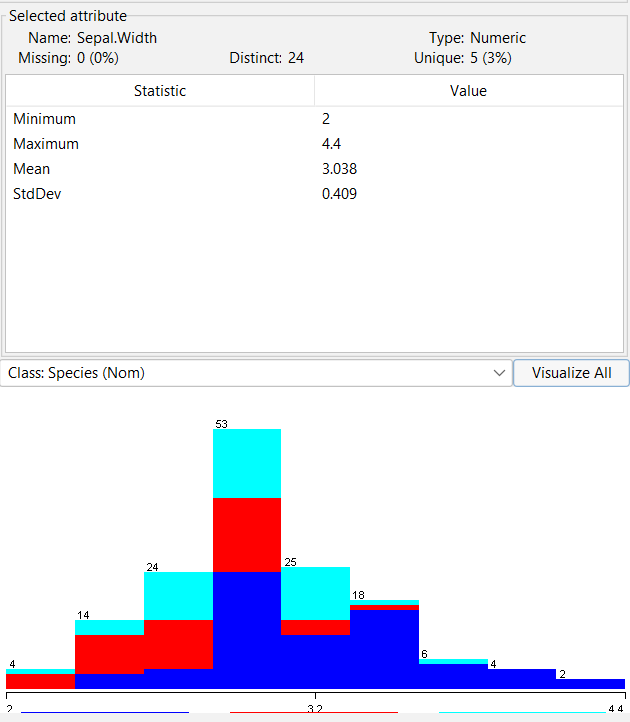

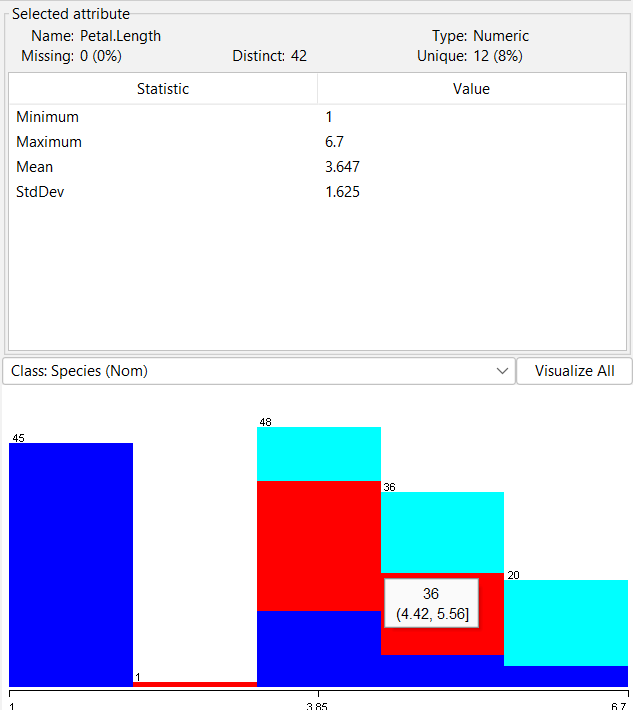

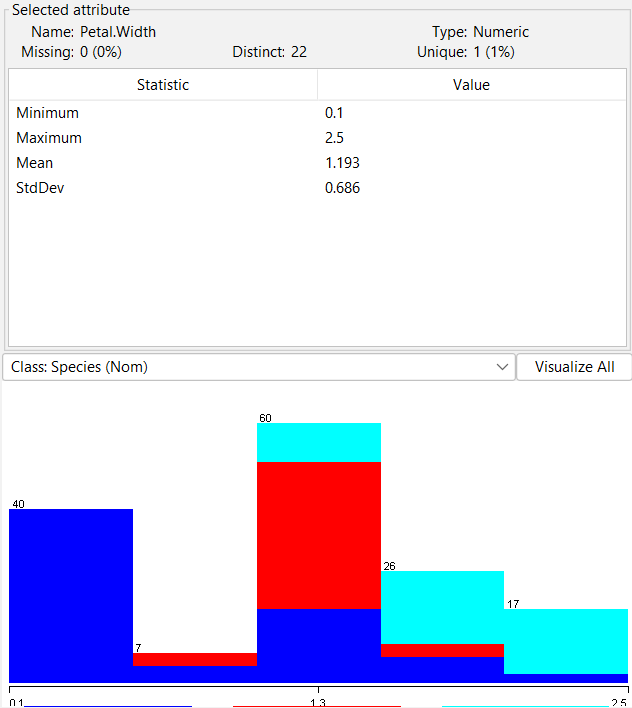

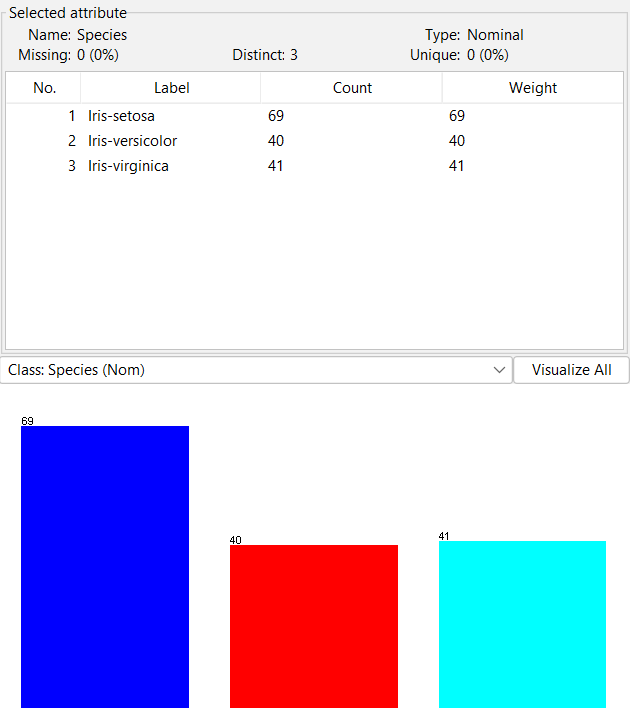

### **Compare Results**

The comparison will be made used the option classify before and after of applying imputation methods.
The algorithm used is J48 tree through 10-fold cross validation.

#### **Classification Before - Original Dataset**

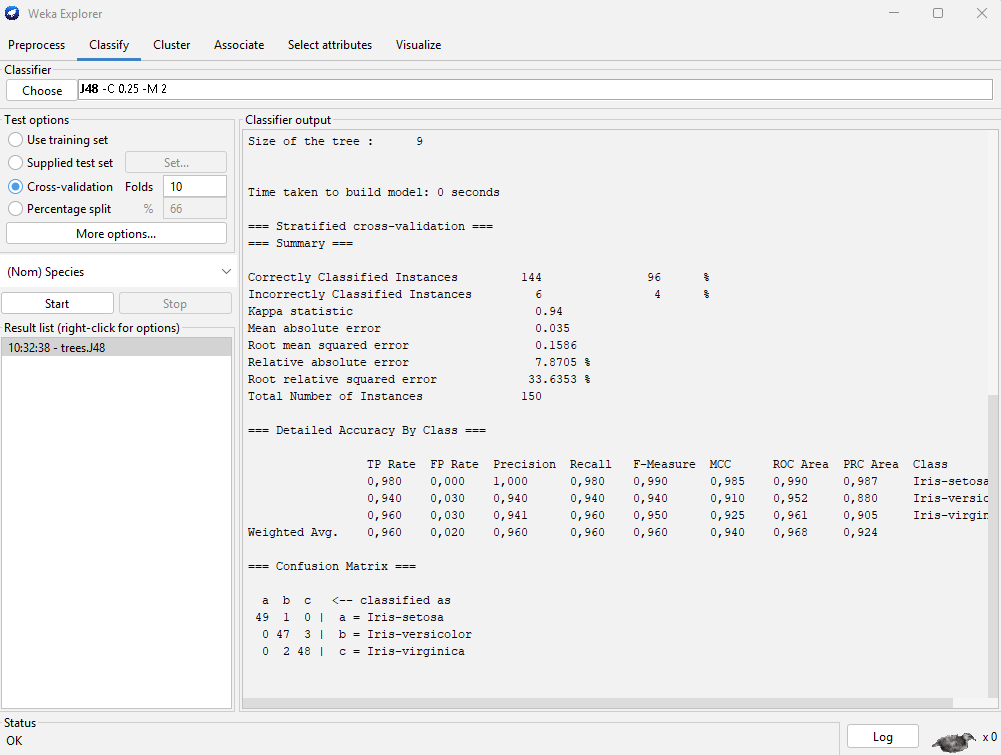

#### **Classification After - Imputed Dataset**

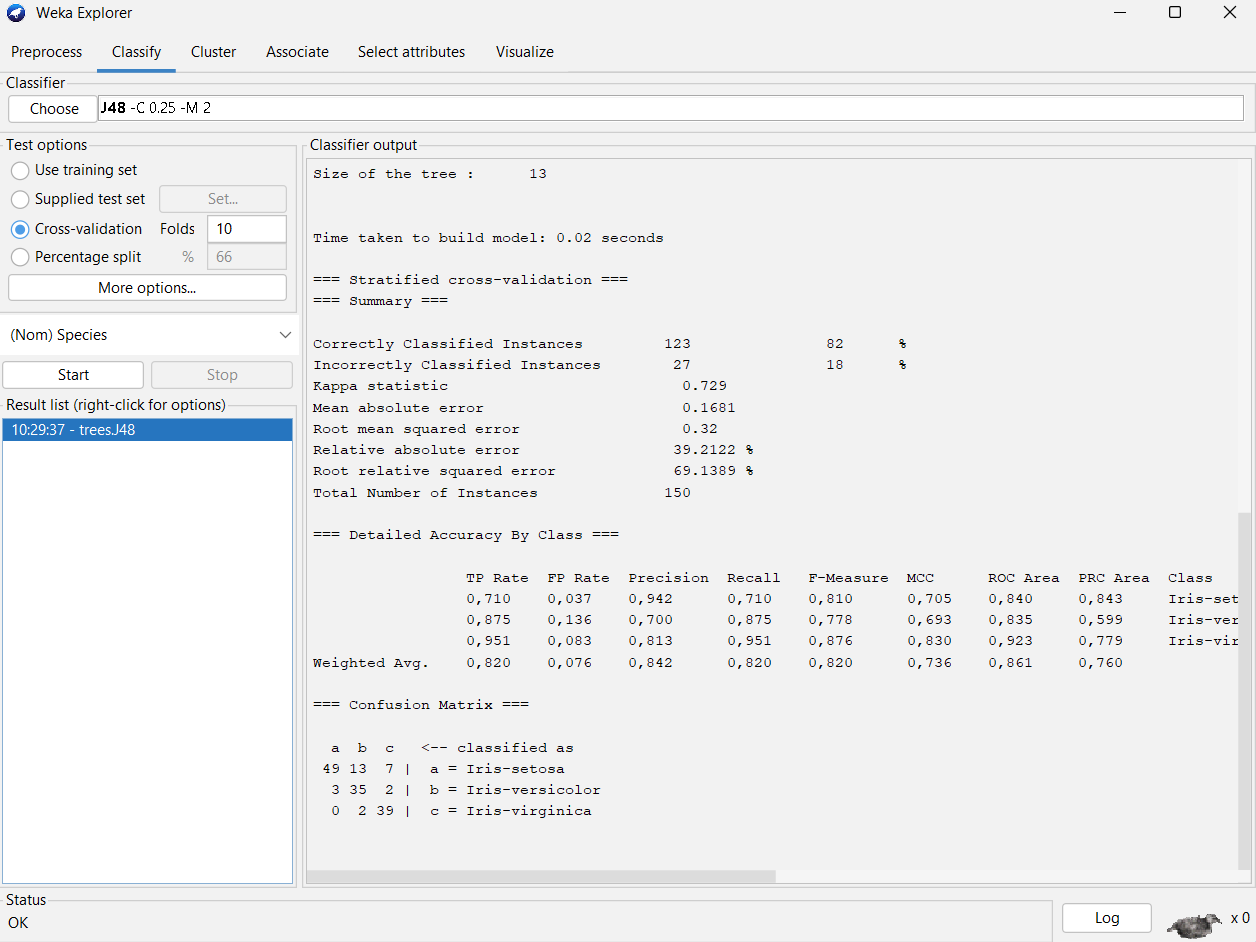

#### **Comparison**

**Dataset:** Iris  
**Classifier:** J48 decision tree  
**Evaluation method:** 10-fold cross-validation in Weka

---

**General Comparison**

| Metric | Original Dataset | Dataset After Missing Values + Imputation |
|------|------|------|
| Correctly Classified Instances | 144 (96%) | 123 (82%) |
| Incorrectly Classified Instances | 6 (4%) | 27 (18%) |
| Kappa Statistic | 0.94 | 0.729 |
| Mean Absolute Error | 0.035 | 0.1681 |
| Root Mean Squared Error | 0.1586 | 0.32 |
| Relative Absolute Error | 7.87% | 39.21% |
| Root Relative Squared Error | 33.64% | 69.14% |
| Number of Instances | 150 | 150 |

The original dataset achieved a significantly higher classification performance. After introducing missing values and applying imputation, the model accuracy decreased by **14 percentage points**, indicating that the presence of missing values and the imputation process negatively impacted the classifier's performance.

---

**Decision Tree Complexity**

| Metric | Original Dataset | After Imputation |
|------|------|------|
| Number of Leaves | 5 | 7 |
| Tree Size | 9 | 13 |

The tree generated from the dataset with missing values is **more complex**, with additional nodes and leaves. This indicates that the classifier required more rules to handle the uncertainty introduced by missing data.

---

**Per-Class Performance**

| Class | Precision (Before) | Precision (After) | Recall (Before) | Recall (After) | F1 (Before) | F1 (After) |
|------|------|------|------|------|------|------|
| Iris-setosa | 1.000 | 0.942 | 0.980 | 0.710 | 0.990 | 0.810 |
| Iris-versicolor | 0.940 | 0.700 | 0.940 | 0.875 | 0.940 | 0.778 |
| Iris-virginica | 0.941 | 0.813 | 0.960 | 0.951 | 0.950 | 0.876 |

The most affected class is **Iris-setosa**, where recall dropped from **0.98 to 0.71**, indicating that more instances of this class were misclassified after the introduction of missing values.

---

**Confusion Matrix Comparison**

Original Dataset:

| Actual \\ Predicted | Setosa | Versicolor | Virginica |
|---|---|---|---|
| Setosa | 49 | 1 | 0 |
| Versicolor | 0 | 47 | 3 |
| Virginica | 0 | 2 | 48 |

After Missing Values + Imputation:

| Actual \\ Predicted | Setosa | Versicolor | Virginica |
|---|---|---|---|
| Setosa | 49 | 13 | 7 |
| Versicolor | 3 | 35 | 2 |
| Virginica | 0 | 2 | 39 |

The confusion matrix shows a **substantial increase in misclassifications**, particularly for **Iris-setosa**, which is frequently misclassified as **Iris-versicolor** after the imputation process.

---

**Conclusion:**

The most notable difference between both experiments is the drop in classification accuracy. The original dataset achieved **96% accuracy**, while the dataset with missing values and subsequent imputation achieved **82% accuracy**. This represents a decrease of **14 percentage points**, showing that the presence of missing values and the imputation process negatively affected the predictive performance of the model.

Another important metric that reflects this change is the **Kappa statistic**, which measures the agreement between predicted and actual classifications. In the original dataset the value was **0.94**, indicating almost perfect agreement, whereas after introducing missing values it dropped to **0.729**, indicating a lower level of reliability in the predictions.

The confusion matrices also reveal a clear increase in classification errors. In the original dataset only **6 instances were misclassified**, while after introducing missing values and applying imputation the number of misclassified instances increased to **27**. This suggests that the imputed values introduced additional uncertainty into the dataset, making it harder for the classifier to identify clear decision boundaries.

The structure of the decision tree also changed. With the original dataset, the generated tree was relatively simple, containing **5 leaves and a total size of 9 nodes**. After the introduction of missing values and imputation, the resulting tree became **more complex**, with **7 leaves and a size of 13 nodes**. This increase in complexity indicates that the model required more rules to compensate for the uncertainty introduced by the missing values.

Overall, the results show that missing data can significantly affect the performance of machine learning models. Even though imputation techniques allow the dataset to remain usable, the reconstructed values may not fully represent the original data distribution. As a consequence, the classifier experiences reduced accuracy and increased model complexity.

### **Normalize Attributes**

Min-Max Normalization used with the filter Normalize

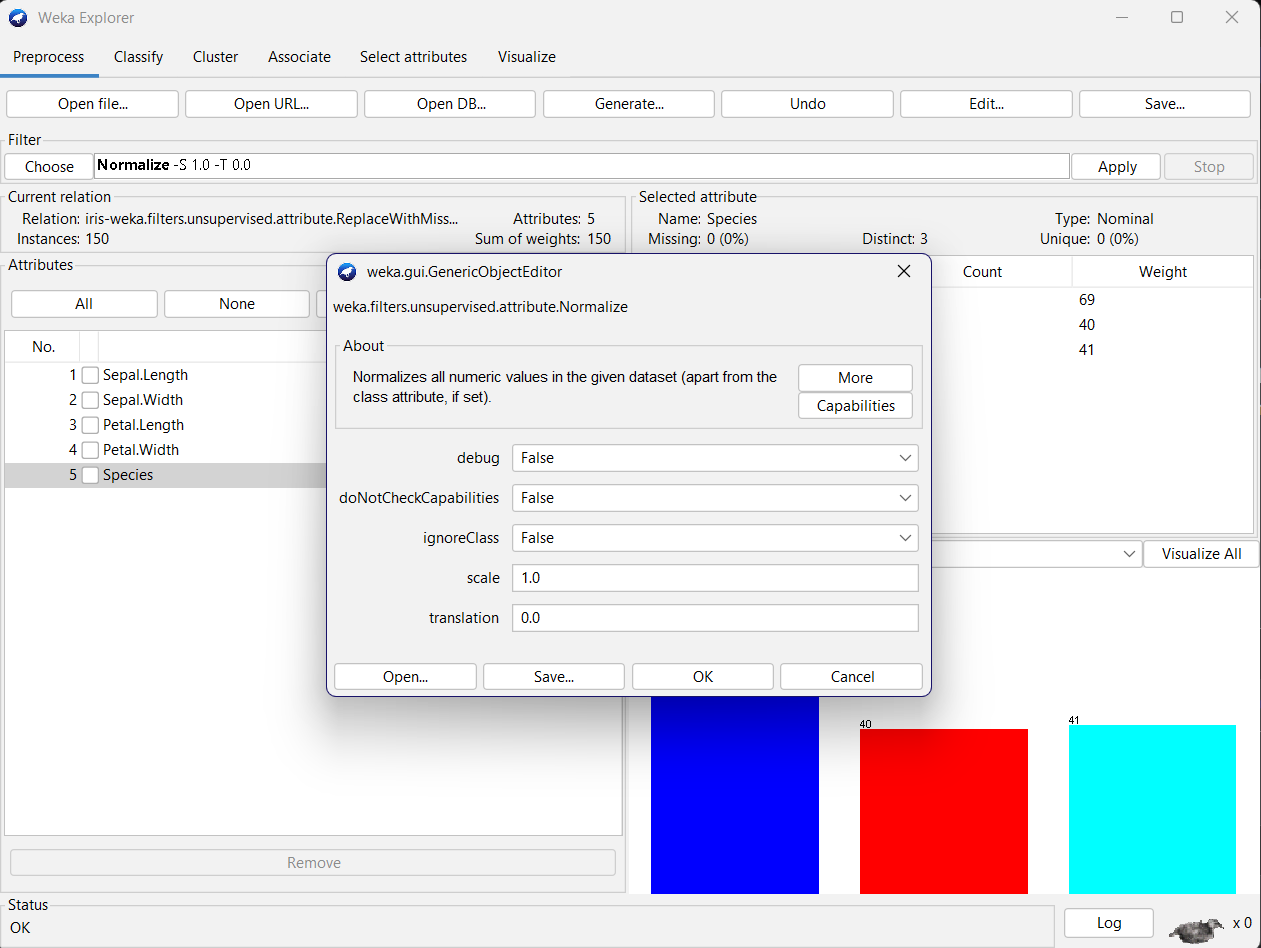

#### **Normalization Results**

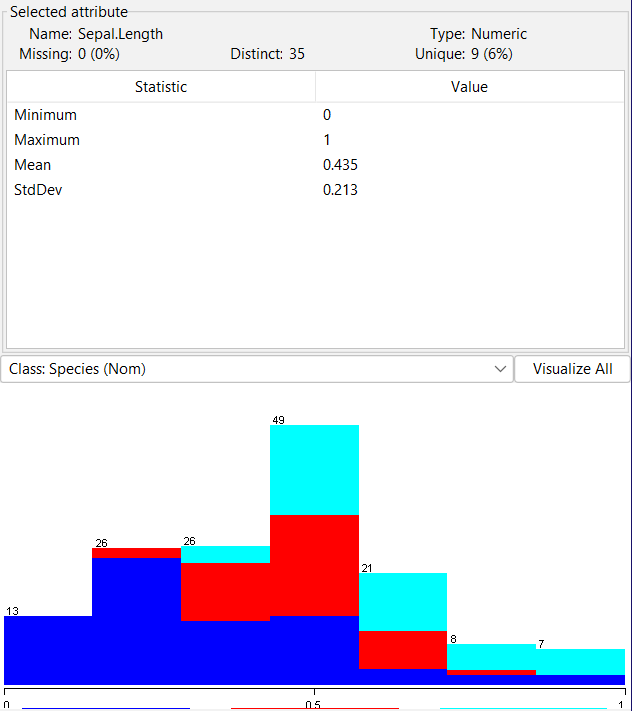
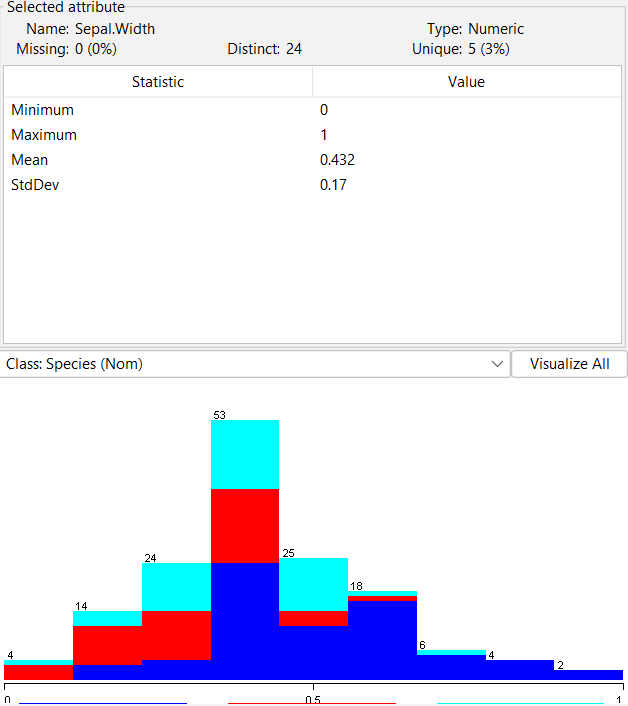
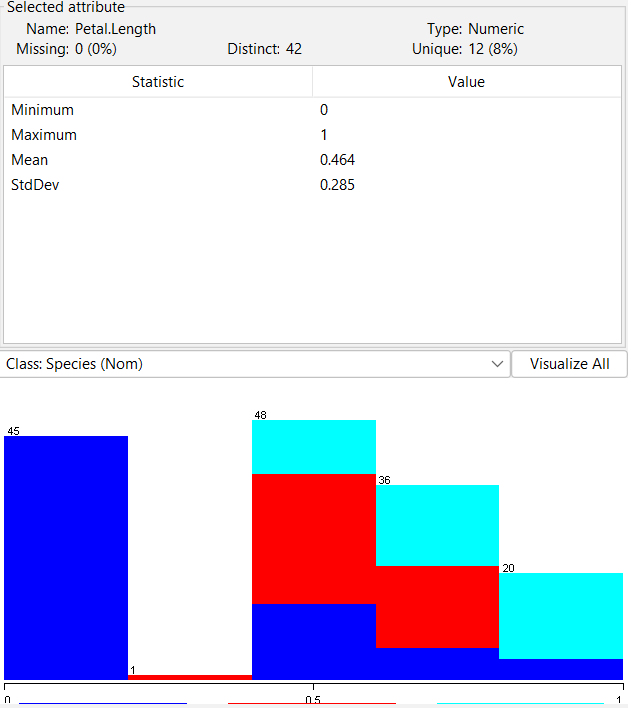
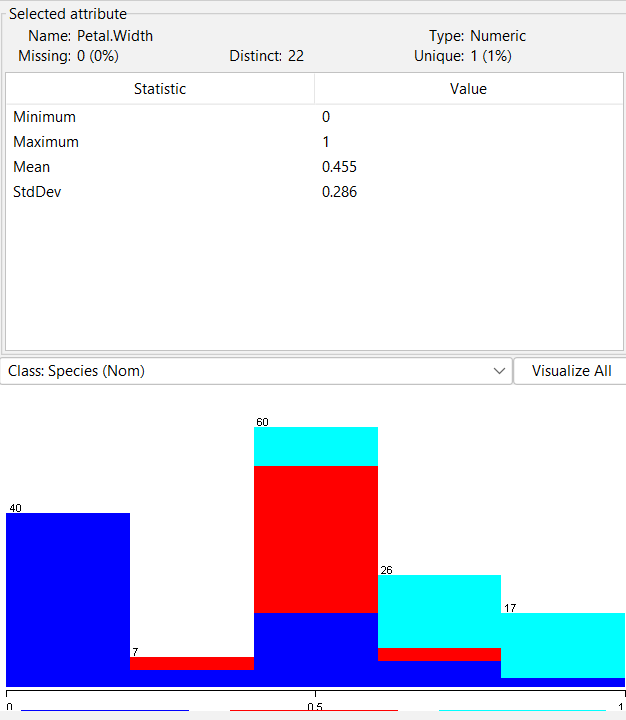

### **Discretize Attributes**

Discretize filter with 4 bins will be used.

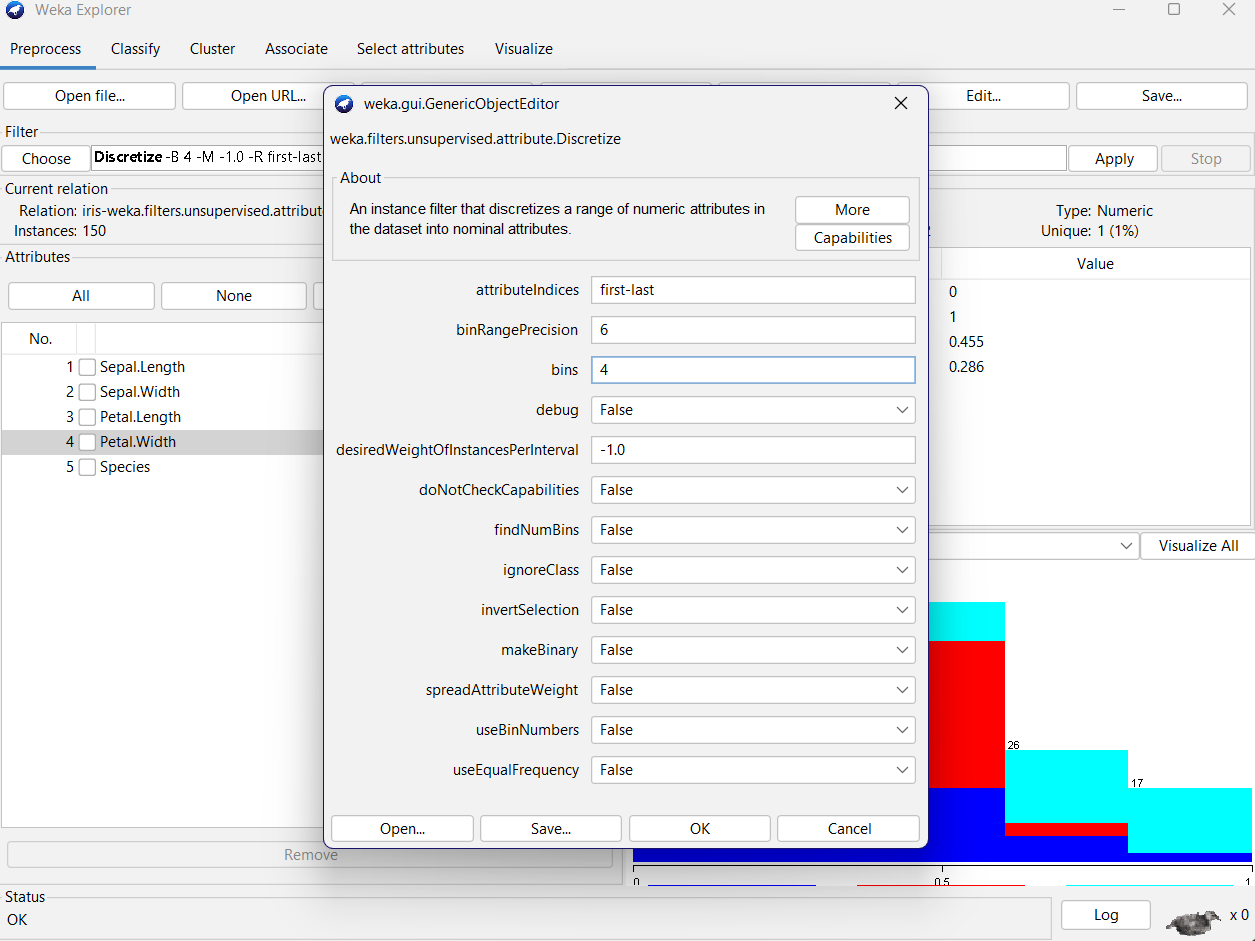

#### **Discretization Results**

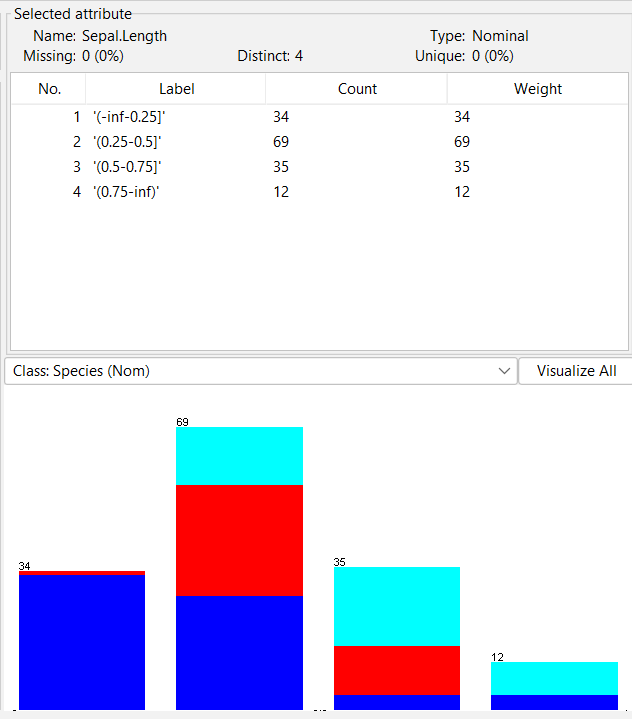

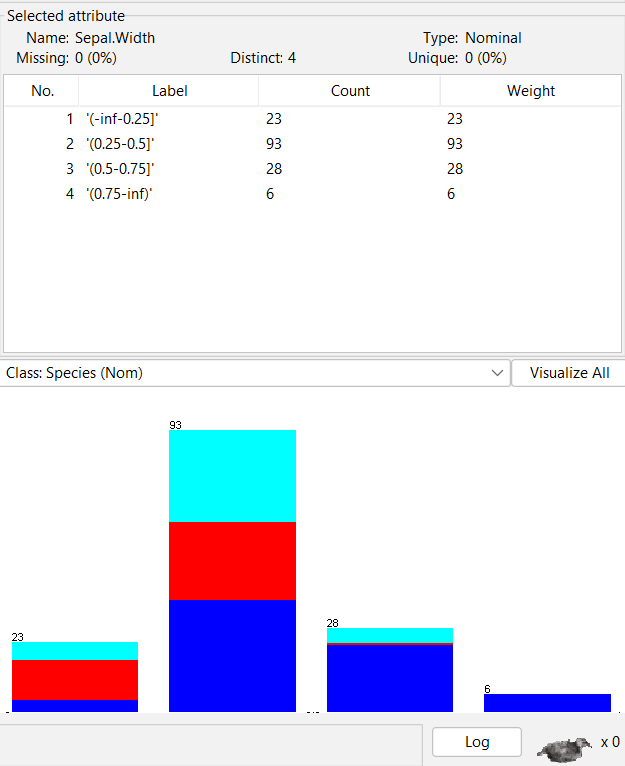

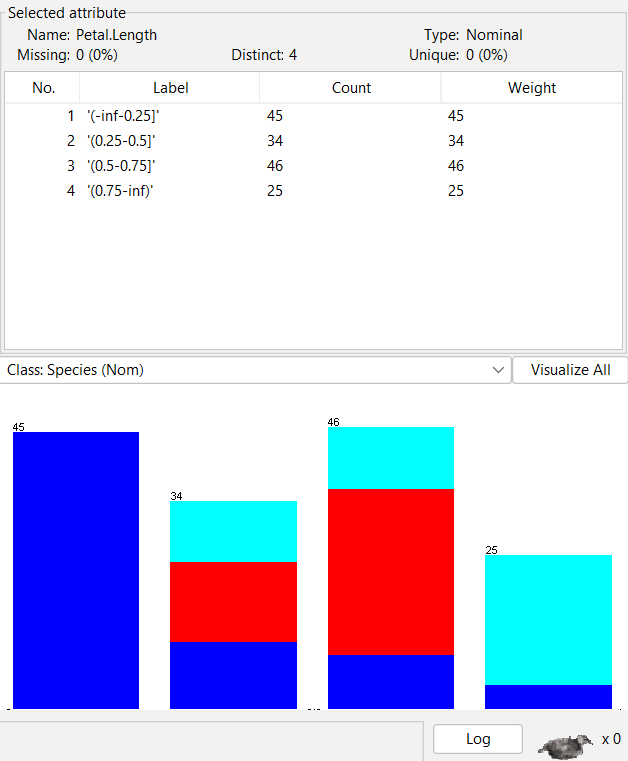

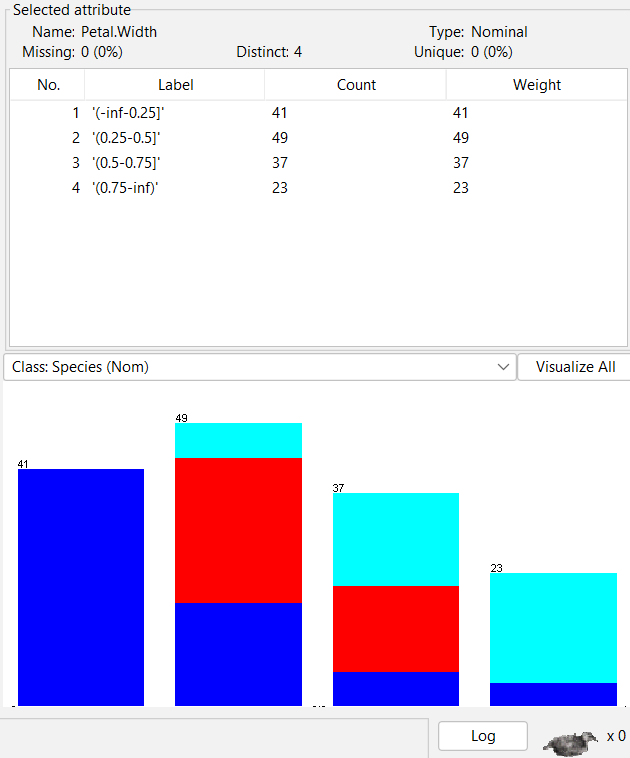

## **6. Reducción de valores mediante Binning**

Dado el conjunto de datos:
|I1|I2|I3|
|--|--|--|
|1|5.9|3.4|
|2|2.1|6.2|
|1|1.6|2.8|
|2|6.8|5.8|
|1|3.1|3.1|
|1|8.3|4.1|
|2|2.4|5.0|

Realizar reducción de valores basado en la técnica de ***BIN*** con el mejor corte para lo siguiente (mostrar pasos):

- Dimensión $I2$ usando la media como representantes de 2 BINS.
- Dimensión $I3$ usando el límite más cercano como representante de 2 BINS.


In [ ]:
binning_dataset = pd.DataFrame([[1, 5.9, 3.4],
                                [2, 2.1, 6.2],
                                [1, 1.6, 2.8],
                                [2, 6.8, 5.8],
                                [1, 3.1, 3.1],
                                [1, 8.3, 4.1],
                                [2, 2.4, 5.0]],
                               columns=['I1', 'I2', 'I3'])

In [ ]:
display(binning_dataset)

,I1,I2,I3
0,1,5.9,3.4
1,2,2.1,6.2
2,1,1.6,2.8
3,2,6.8,5.8
4,1,3.1,3.1
5,1,8.3,4.1
6,2,2.4,5.0


In [ ]:
def BIN_error(original, binned):
    error = 0
    for o, b in zip(original, binned):
        error += (o - b) ** 2
    return error

In [ ]:
def find_best_BIN(original, representative='mean'):
    original = np.sort(original)
    best_error = float('inf')
    best_binned = None
    bin_index = 1

    if len(original) < 2:
        print("Cannot perform binning into 2 bins with less than 2 elements.")
        return None, None, None

    for i in range(1, len(original)):
        g1 = original[:i]
        g2 = original[i:]

        if len(g1) == 0 or len(g2) == 0:
            continue

        if representative == 'mean':
            binned_g1 = [np.mean(g1)] * len(g1)
            binned_g2 = [np.mean(g2)] * len(g2)
            binned = binned_g1 + binned_g2
        elif representative == 'nearest':
            binned_g1 = []
            g1_min = g1[0]
            g1_max = g1[-1]
            for x in g1:
                if abs(x - g1_min) < abs(x - g1_max):
                    binned_g1.append(g1_min)
                else:
                    binned_g1.append(g1_max)

            binned_g2 = []
            g2_min = g2[0]
            g2_max = g2[-1]
            for x in g2:
                if abs(x - g2_min) < abs(x - g2_max):
                    binned_g2.append(g2_min)
                else:
                    binned_g2.append(g2_max)
            binned = binned_g1 + binned_g2

        error = BIN_error(original, binned)

        binned_clean = [float(x) for x in binned]

        if error < best_error:
            best_error = error
            best_binned = binned
            bin_index = i

    if best_binned is None:
        print("No valid binning found.")
        return None, None, None

    print(f"Best BIN found in the index {bin_index} and error {best_error}")
    print(f"Original Sorted Attribute: {[float(x) for x in original]}")
    print(f"Best Bin: {[float(x) for x in best_binned]}")
    print("Groups:")
    print(f"Group 1: {[float(x) for x in original[:bin_index]]}")
    print(f"Group 2: {[float(x) for x in original[bin_index:]]}")
    return best_binned, best_error, bin_index

In [ ]:
I2 = np.array(binning_dataset['I2'])
I3 = np.array(binning_dataset['I3'])

In [ ]:
print('')
best_binned_I2, best_error_I2, bin_index_I2 = find_best_BIN(I2, representative='mean')


Best BIN found in the index 4 and error 4.120000000000001
Original Sorted Attribute: [1.6, 2.1, 2.4, 3.1, 5.9, 6.8, 8.3]
Best Bin: [2.3, 2.3, 2.3, 2.3, 7.0, 7.0, 7.0]
Groups:
Group 1: [1.6, 2.1, 2.4, 3.1]
Group 2: [5.9, 6.8, 8.3]


In [ ]:
best_binned_I3, best_error_I3, bin_index_I3 = find_best_BIN(I3, representative='nearest')

Best BIN found in the index 4 and error 0.6100000000000005
Original Sorted Attribute: [2.8, 3.1, 3.4, 4.1, 5.0, 5.8, 6.2]
Best Bin: [2.8, 2.8, 2.8, 4.1, 5.0, 6.2, 6.2]
Groups:
Group 1: [2.8, 3.1, 3.4, 4.1]
Group 2: [5.0, 5.8, 6.2]


In [ ]:
binned_dataset = binning_dataset.copy()

# Ordenar el dataset por la columna 'I2' de menor a mayor
binned_dataset = binned_dataset.sort_values(by='I2', ascending=True)
binned_dataset['I2'] = best_binned_I2

binned_dataset = binned_dataset.sort_values(by='I3', ascending=True)
binned_dataset['I3'] = best_binned_I3
print("Original Dataset:")
display(binning_dataset)

print("\nBinned Dataset:")
display(binned_dataset)

Original Dataset:


,I1,I2,I3
0,1,5.9,3.4
1,2,2.1,6.2
2,1,1.6,2.8
3,2,6.8,5.8
4,1,3.1,3.1
5,1,8.3,4.1
6,2,2.4,5.0



Binned Dataset:


,I1,I2,I3
2,1,2.3,2.8
4,1,2.3,2.8
0,1,7.0,2.8
5,1,7.0,4.1
6,2,2.3,5.0
3,2,7.0,6.2
1,2,2.3,6.2


## **8. Dataset Adult**


Al conjunto de datos Adult del repositorio de Machine Learning(https://archive.ics.uci.edu/dataset/2/adult):

- Convertir todos los atributos numéricos a categóricos utilizando dos estrategias diferentes.
- Transformar el conjunto de datos de manera que todos los atributos sean numéricos.

### **Load Dataset**

In [ ]:
column_names = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]
adult_df = pd.read_csv('./adult.data', names=column_names)

In [ ]:
display(adult_df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
adult_df.shape

(32561, 15)

### **Get Numerical Attributes**

In [ ]:
numerical_cols_adult_df = adult_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
print(numerical_cols_adult_df)

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


### **Convert Numerical Attributes to Categorical Ones**

In [ ]:
def plot_frequency_distribution(column_data, column_name="Column"):
    plt.figure(figsize=(10, 6))
    column_data.value_counts().sort_index().plot(kind='bar')
    plt.title(f'Frequency Plot for {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_histogram_distribution(column_data, column_name="Column"):
    plt.figure(figsize=(10, 6))
    sns.histplot(column_data, kde=True)
    plt.title(f'Hystogram for {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

#### Strategy 1 - Equal Width Binning

In [ ]:
adult_df_strategy_1 = adult_df.copy()

Age

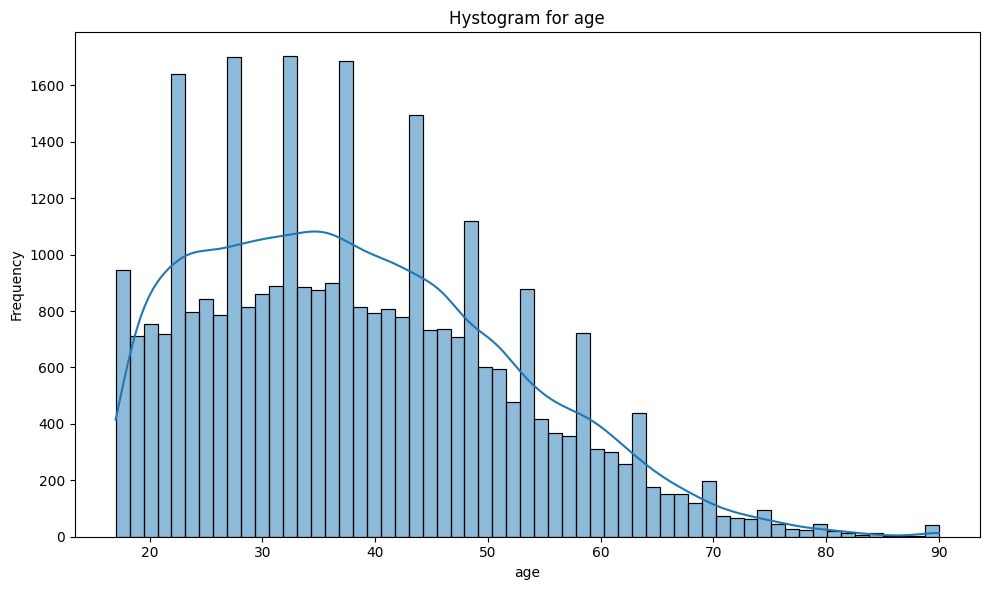

In [ ]:
plot_histogram_distribution(adult_df_strategy_1['age'], 'age')

In [ ]:
adult_df_strategy_1['age'] = pd.cut(adult_df_strategy_1['age'], bins=5,
                                    labels = ['Young', 'Pre-Adult', 'Adult', 'Middle-age', 'Senior'])
adult_df_strategy_1['age'].value_counts()

,count
age,
Pre-Adult,12211
Young,11460
Adult,6558
Middle-age,2091
Senior,241


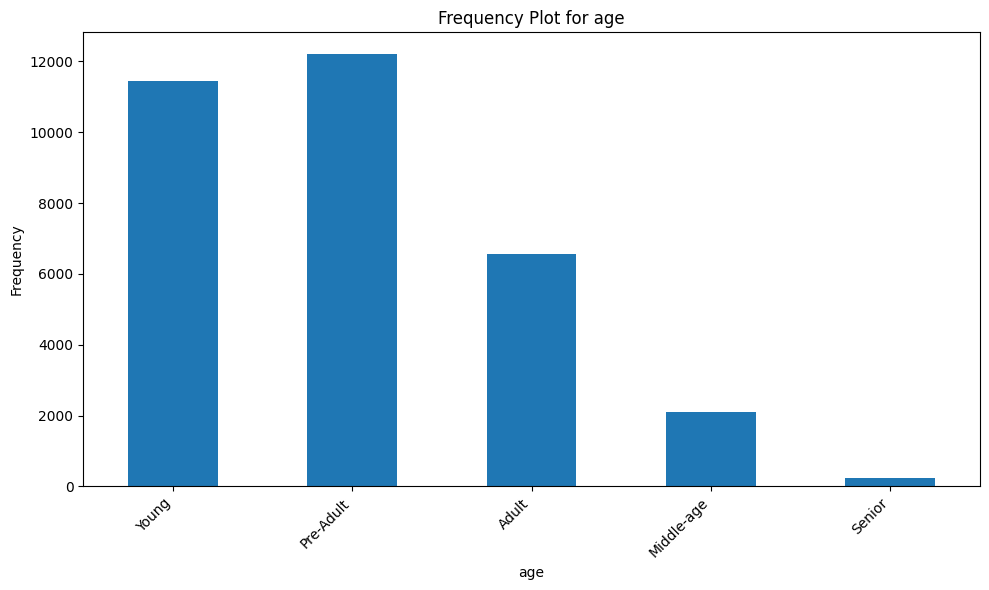

In [ ]:
plot_frequency_distribution(adult_df_strategy_1['age'], 'age')

fnlwgt

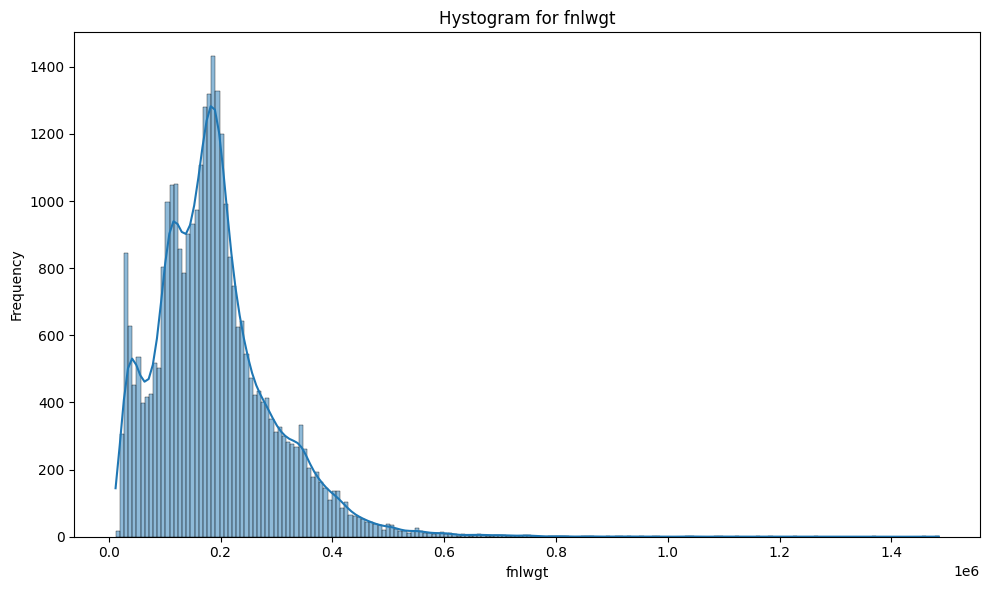

In [ ]:
plot_histogram_distribution(adult_df_strategy_1['fnlwgt'], 'fnlwgt')

In [ ]:
adult_df_strategy_1['fnlwgt'] = pd.cut(adult_df_strategy_1['fnlwgt'], bins=5,
                                       labels = ['Low',  'Medium', 'High', 'Very High', 'Extremely High'])

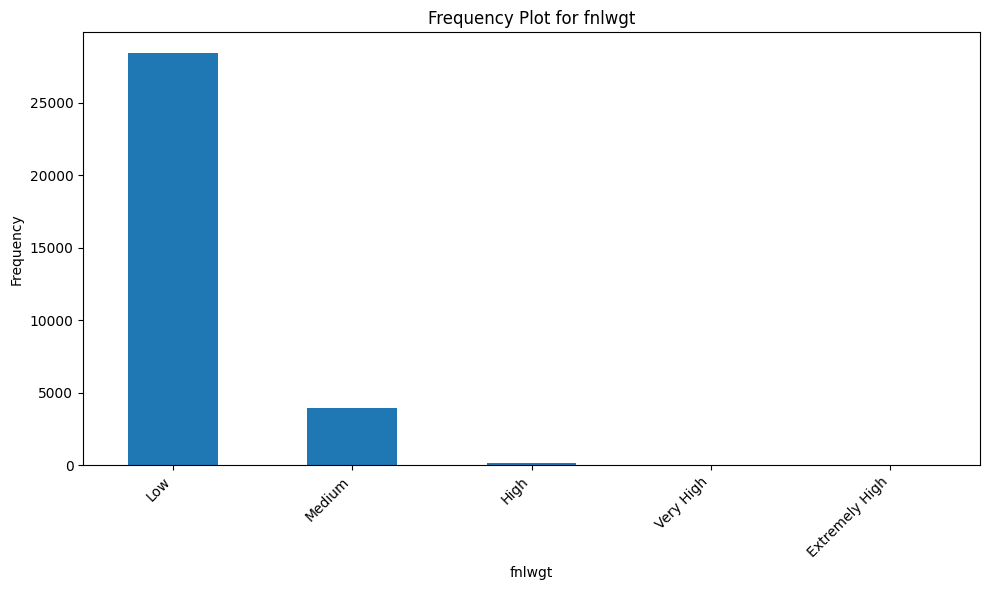

In [ ]:
plot_frequency_distribution(adult_df_strategy_1['fnlwgt'], 'fnlwgt')

Education-num

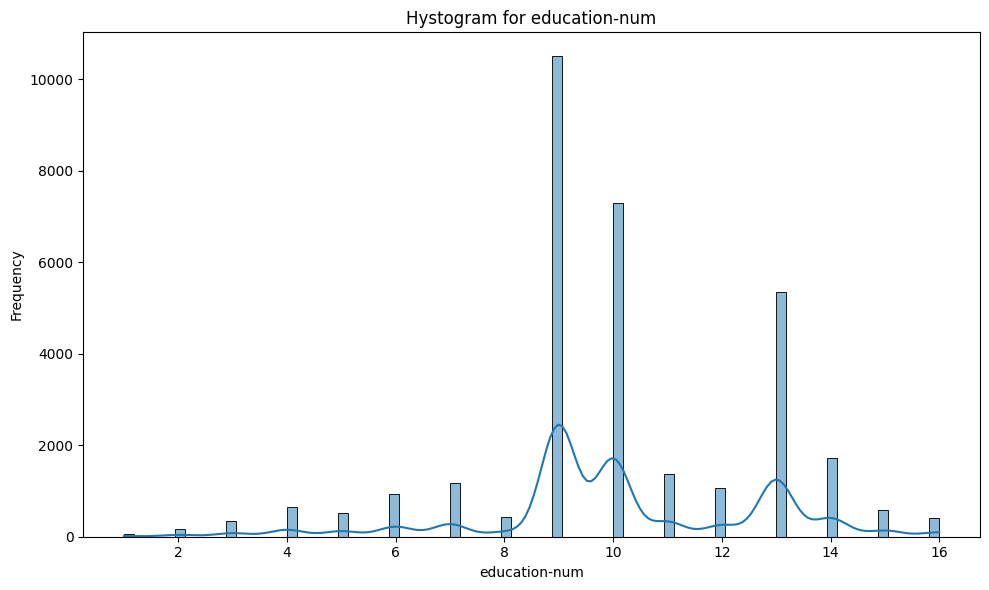

In [ ]:
plot_histogram_distribution(adult_df_strategy_1['education-num'], 'education-num')

In [ ]:
adult_df_strategy_1['education-num'] = pd.cut(adult_df_strategy_1['education-num'], bins=4,
                                              labels=["Very Low Education", "Low Education", "Medium Education", "High Education"]
                                              )

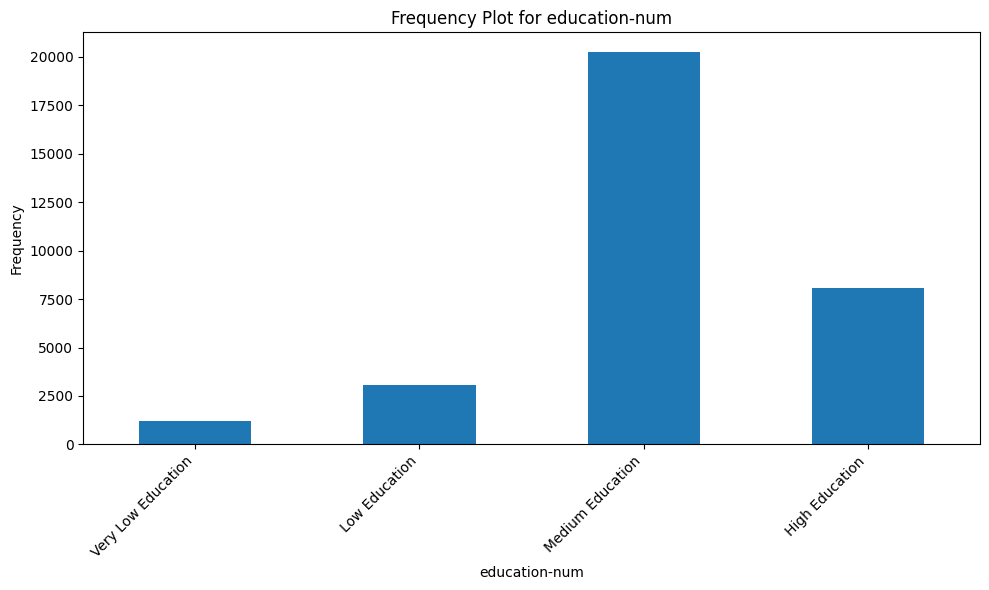

In [ ]:
plot_frequency_distribution(adult_df_strategy_1['education-num'], 'education-num')

Capital-gain

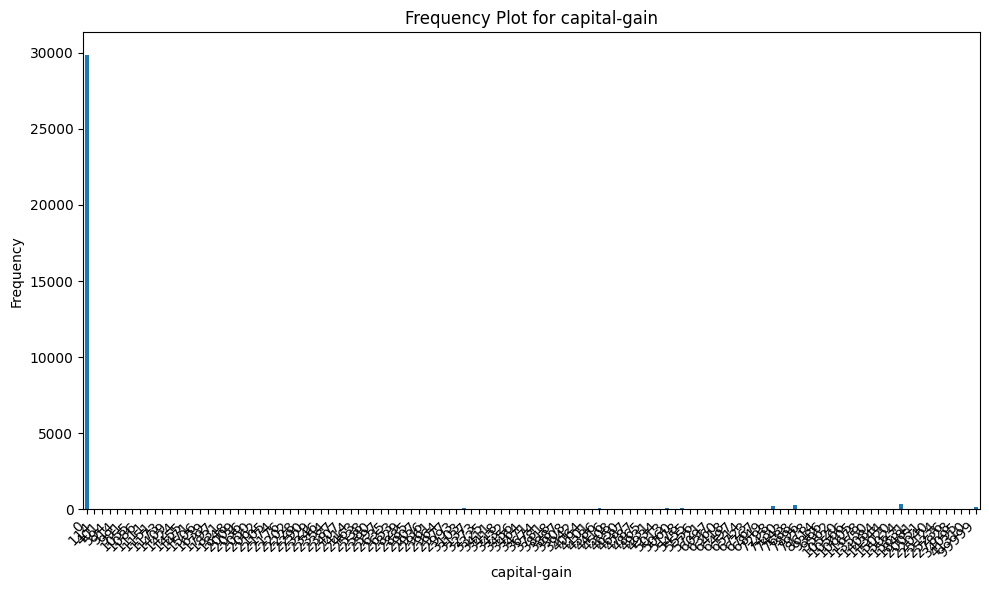

In [ ]:
plot_frequency_distribution(adult_df_strategy_1['capital-gain'], 'capital-gain')

In [ ]:
adult_df_strategy_1['capital-gain'] = pd.cut(adult_df_strategy_1['capital-gain'], bins=4,
                                              labels=["No Gain", "Low Gain", "Medium Gain", "High Gain"]
                                              )

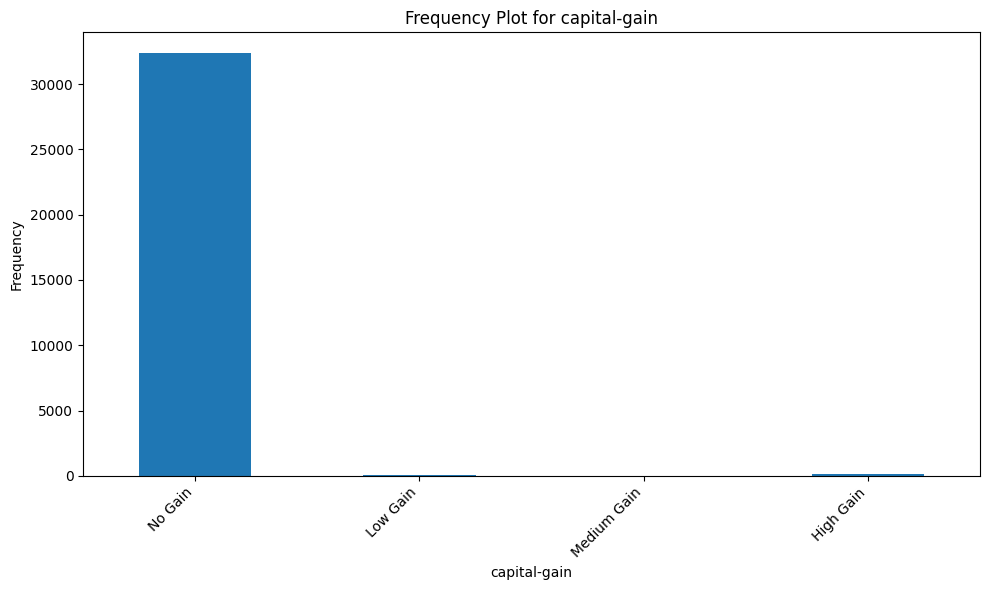

In [ ]:
plot_frequency_distribution(adult_df_strategy_1['capital-gain'], 'capital-gain')

Capital-loss

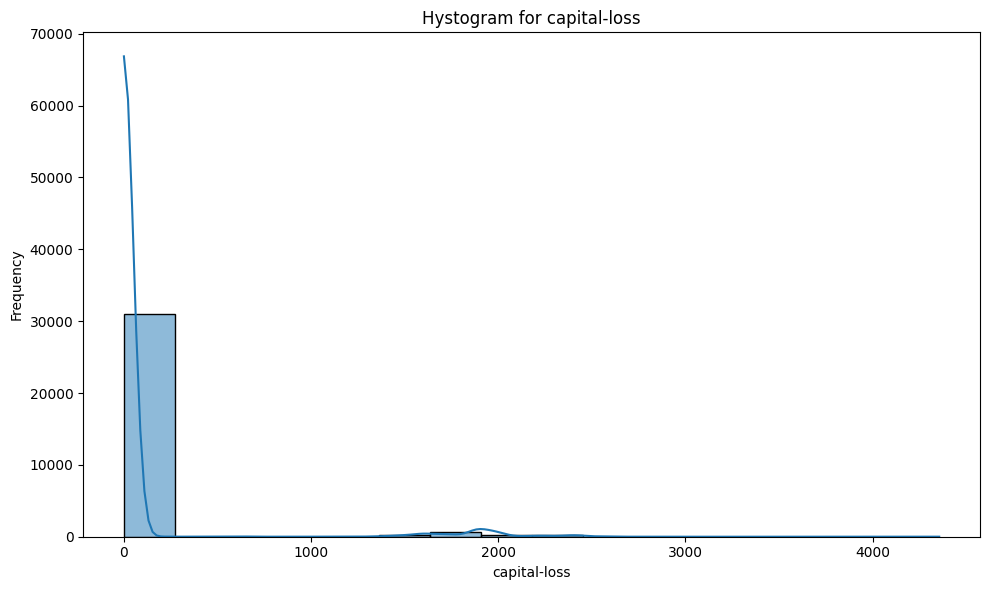

In [ ]:
plot_histogram_distribution(adult_df_strategy_1['capital-loss'], 'capital-loss')

In [ ]:
adult_df_strategy_1['capital-loss'] = pd.cut(adult_df_strategy_1['capital-loss'],
                                             bins = 4,
                                             labels = [
                                                "No Loss",
                                                "Low Loss",
                                                "Medium Loss",
                                                "High Loss"
                                            ])

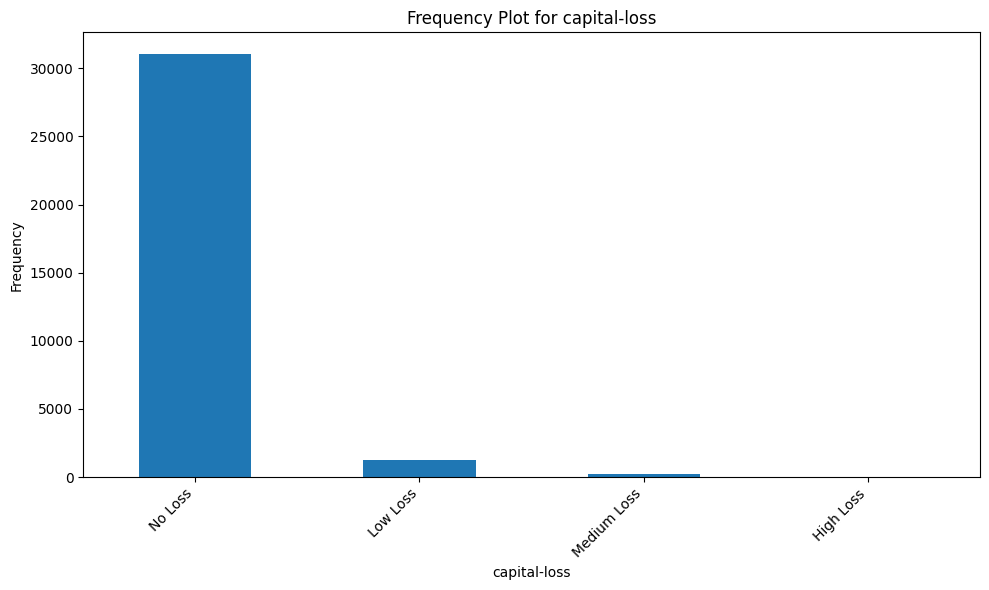

In [ ]:
plot_frequency_distribution(adult_df_strategy_1['capital-loss'], 'capital-loss')

Hours-per-week

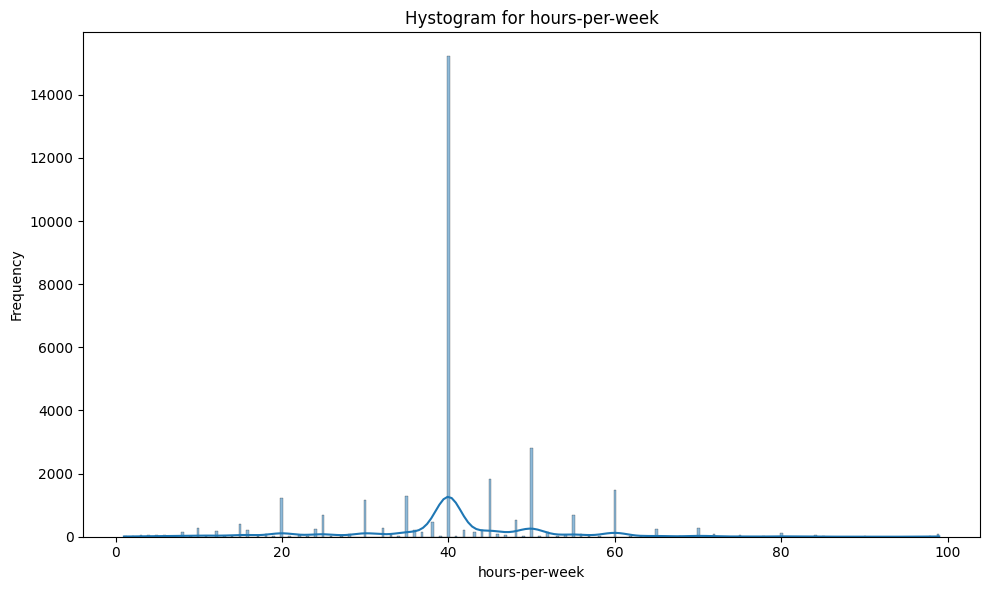

In [ ]:
plot_histogram_distribution(adult_df_strategy_1['hours-per-week'], 'hours-per-week')

In [ ]:
adult_df_strategy_1['hours-per-week'] = pd.cut(adult_df_strategy_1['hours-per-week'], bins=5,
                                               labels = [
                                                   'Very Low Hours',
                                                   'Low Hours',
                                                   'Medium Hours',
                                                   'High Hours',
                                                   'Very High Hours'
                                               ])

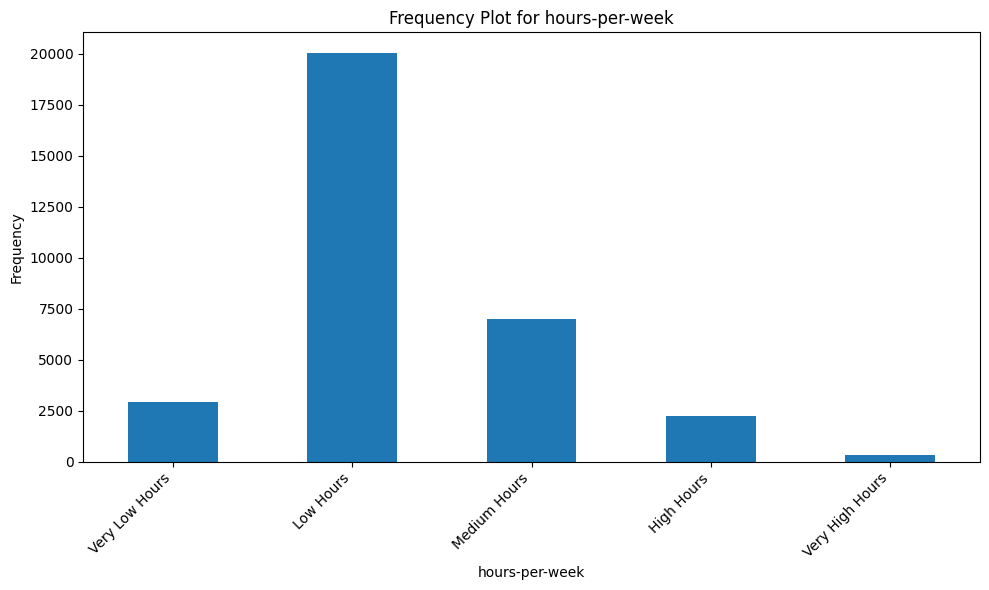

In [ ]:
plot_frequency_distribution(adult_df_strategy_1['hours-per-week'], 'hours-per-week')

#### Strategy 2 - Equal Frequency Binning

In [ ]:
adult_df_strategy_2 = adult_df.copy()

Age

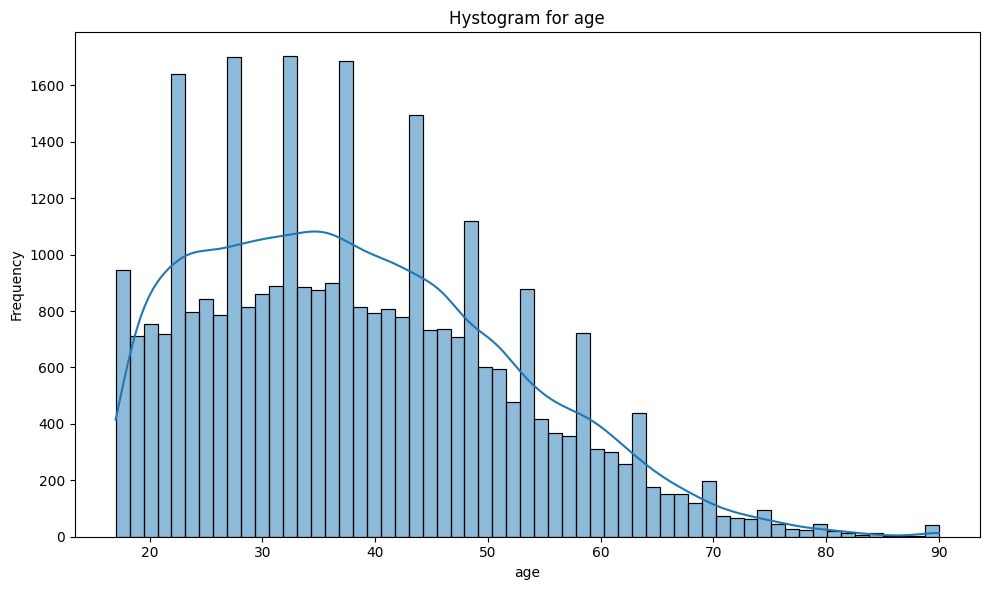

In [ ]:
plot_histogram_distribution(adult_df_strategy_2['age'], 'age')

In [ ]:
adult_df_strategy_2['age'] = pd.qcut(adult_df_strategy_2['age'], q=5,
                                     labels = ['Young', 'Pre-Adult', 'Adult', 'Middle-age', 'Senior']
                                    )

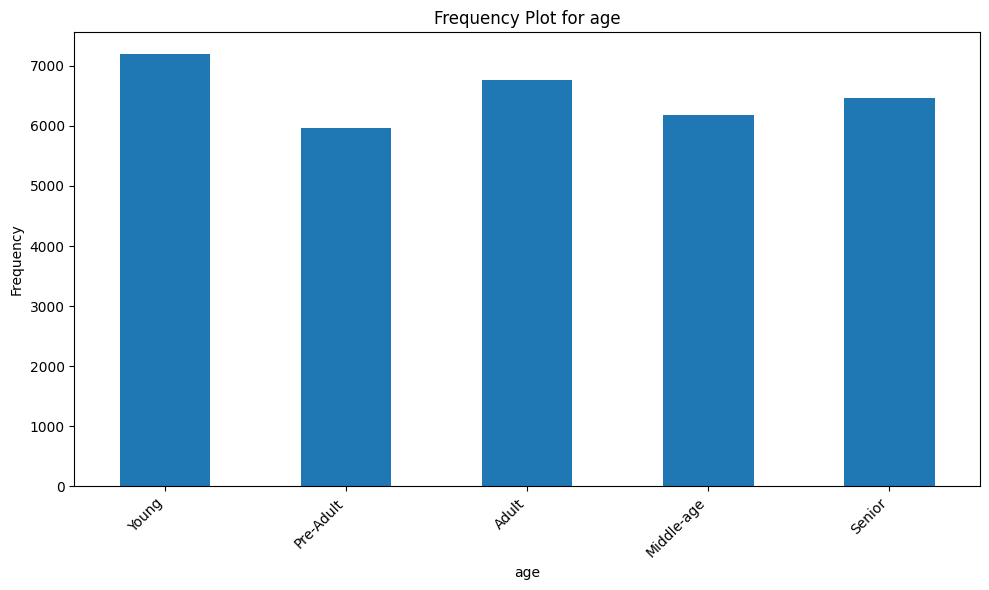

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['age'], 'age')

fnlgwt

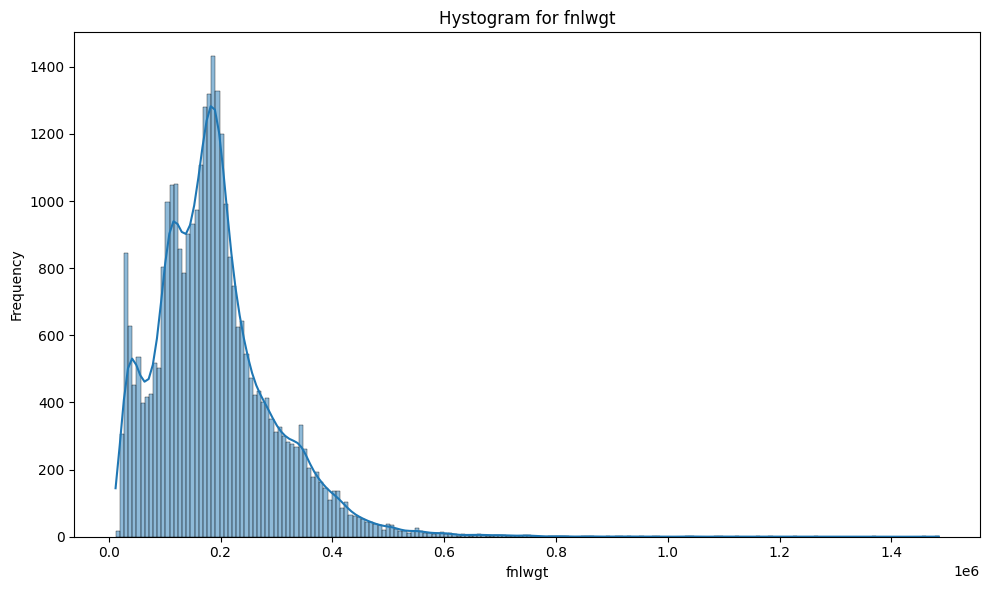

In [ ]:
plot_histogram_distribution(adult_df_strategy_2['fnlwgt'], 'fnlwgt')

In [ ]:
adult_df_strategy_2['fnlwgt'] = pd.qcut(adult_df_strategy_2['fnlwgt'], q=5,
                                        labels = ['Low',  'Medium', 'High', 'Very High', 'Extremely High'])

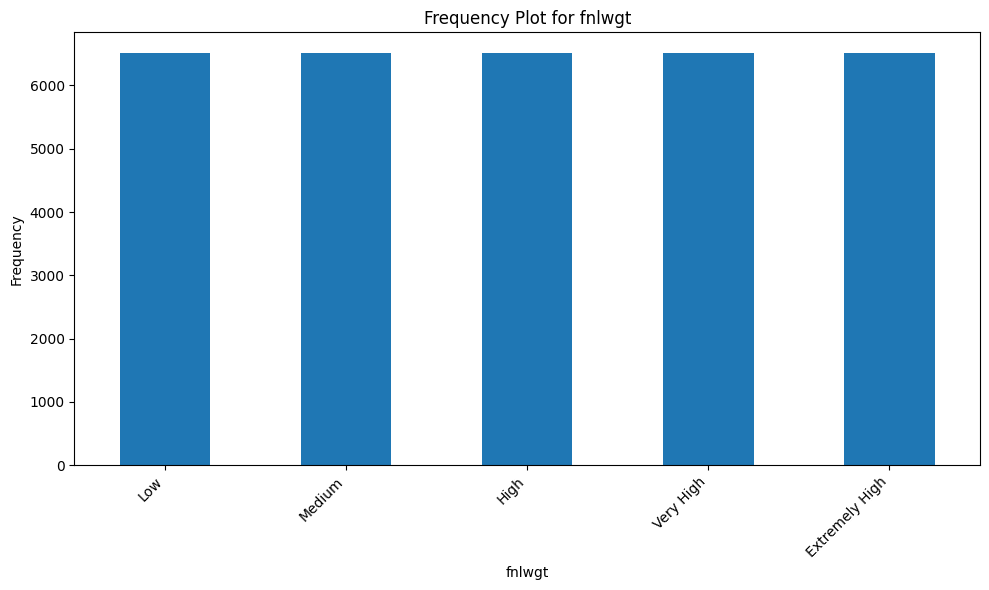

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['fnlwgt'], 'fnlwgt')

Education-num

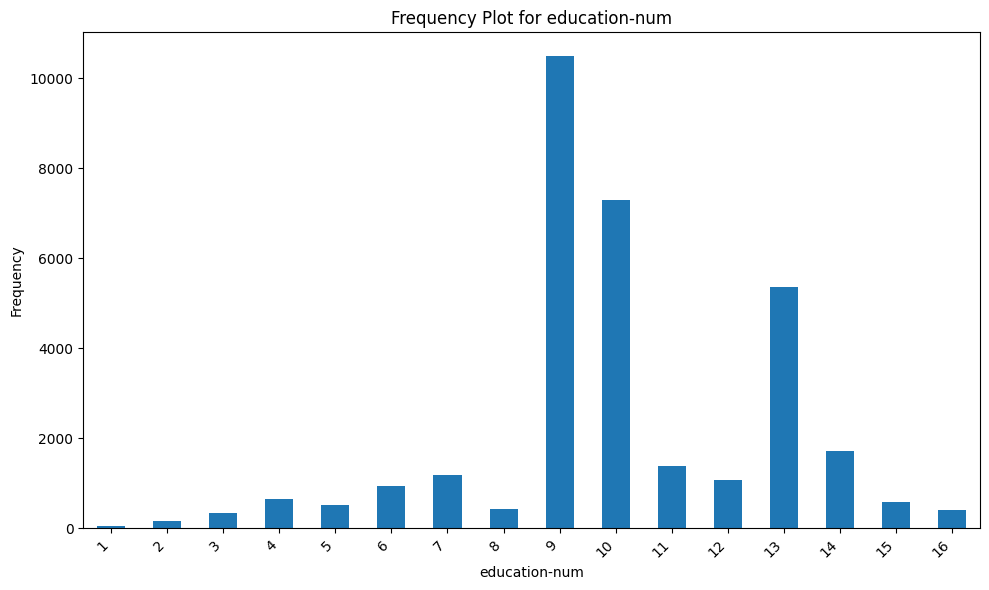

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['education-num'], 'education-num')

In [ ]:
adult_df_strategy_2['education-num'] = pd.qcut(adult_df_strategy_2['education-num'], q=4,
                                               labels=["Very Low Education", "Low Education", "Medium Education", "High Education"])

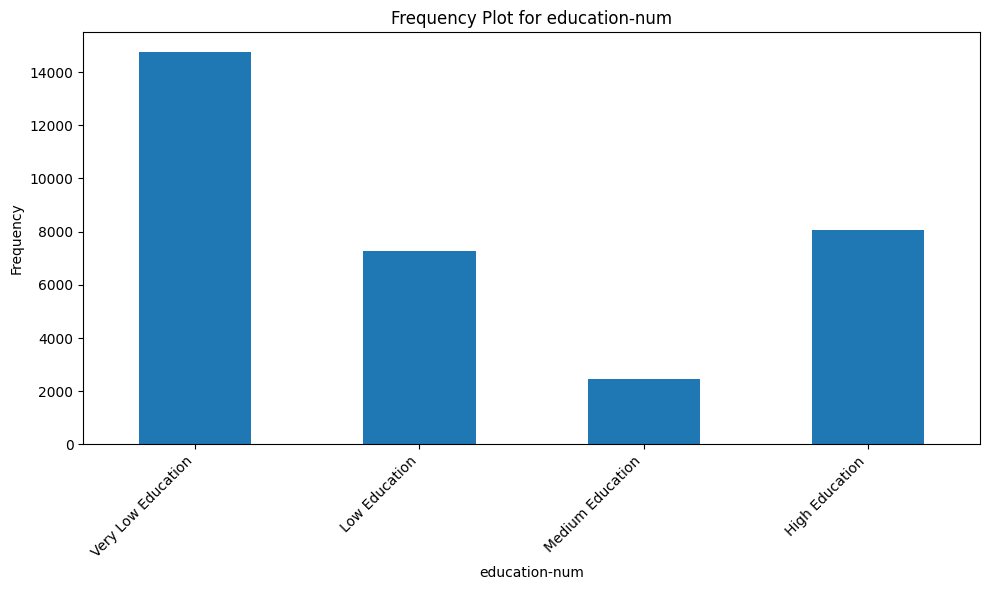

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['education-num'], 'education-num')

Capital-gain

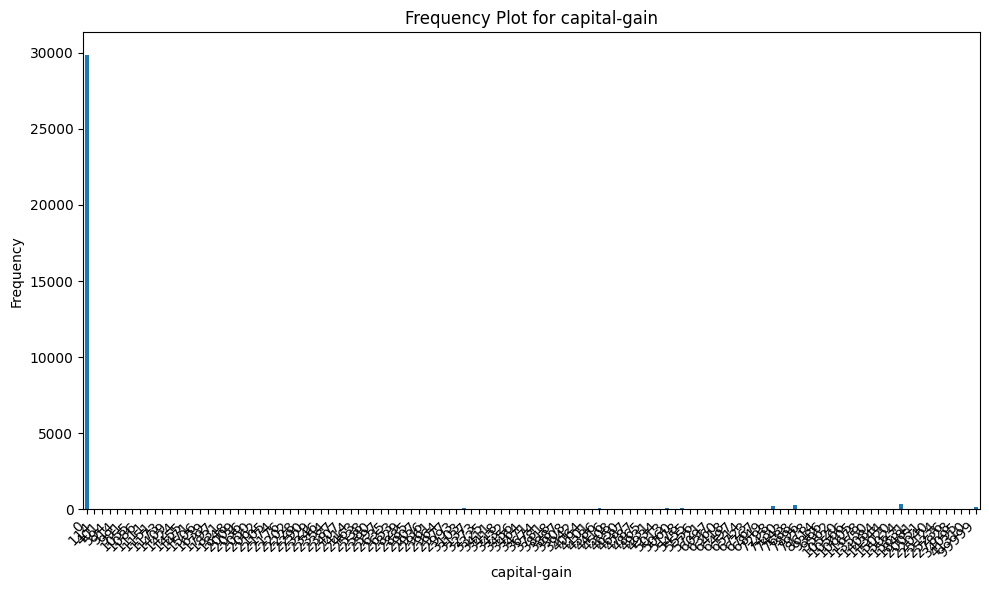

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['capital-gain'], 'capital-gain')

In [ ]:
# Identify non-zero capital-gain values
non_zero_gain = adult_df_strategy_2[adult_df_strategy_2['capital-gain'] > 0]['capital-gain']

# Define custom bins for non-zero values
if non_zero_gain.nunique() > 1:
    # Using qcut to find appropriate quantiles for bin edges
    quantiles = non_zero_gain.quantile([0.33, 0.66]).values
    bins = np.unique(np.concatenate(([0], quantiles, [non_zero_gain.max()])))

    # Make sure we have at least 2 edges to create 1 bin or more
    if len(bins) > 1:
        labels = ['Low Gain', 'Medium Gain', 'High Gain']
        # Adjust labels if fewer than 3 bins are actually created
        if len(bins) - 1 < len(labels):
            labels = labels[:len(bins) - 1]

        adult_df_strategy_2['capital-gain'] = adult_df_strategy_2['capital-gain'].apply(lambda x: 'No Gain' if x == 0 else pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0])
    else:
        adult_df_strategy_2['capital-gain'] = adult_df_strategy_2['capital-gain'].apply(lambda x: 'No Gain' if x == 0 else 'Some Gain')
else:
    adult_df_strategy_2['capital-gain'] = adult_df_strategy_2['capital-gain'].apply(lambda x: 'No Gain' if x == 0 else 'Some Gain')

# Ensure 'No Gain' is always a category
current_categories = adult_df_strategy_2['capital-gain'].astype('category').cat.categories.tolist()
if 'No Gain' not in current_categories:
    current_categories.insert(0, 'No Gain')

# Convert the final column to a Categorical type with explicit categories
adult_df_strategy_2['capital-gain'] = pd.Categorical(adult_df_strategy_2['capital-gain'], categories=current_categories, ordered=True)

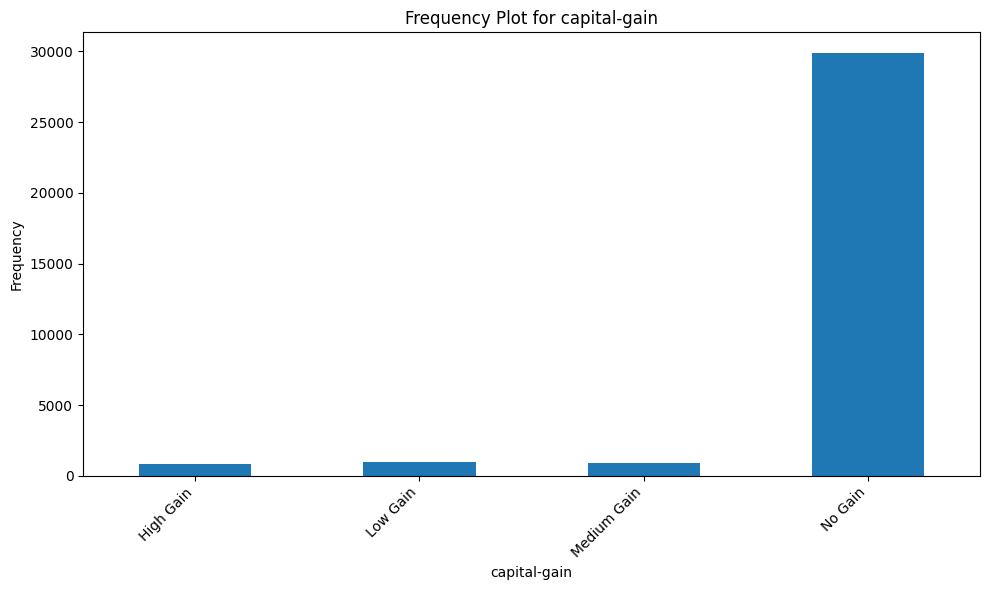

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['capital-gain'], 'capital-gain')

Capital-loss

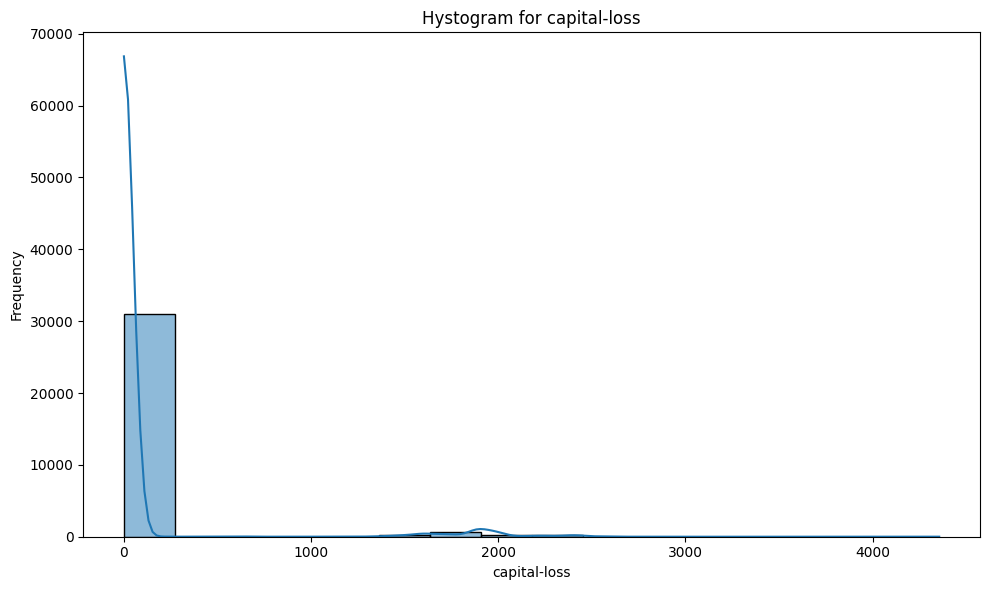

In [ ]:
plot_histogram_distribution(adult_df_strategy_2['capital-loss'], 'capital-loss')

In [ ]:
# Identify non-zero capital-loss values
non_zero_loss = adult_df_strategy_2[adult_df_strategy_2['capital-loss'] > 0]['capital-loss']

# Define custom bins for non-zero values
if non_zero_loss.nunique() > 1:
    # Using qcut to find appropriate quantiles for bin edges
    quantiles = non_zero_loss.quantile([0.33, 0.66]).values
    bins = np.unique(np.concatenate(([0], quantiles, [non_zero_loss.max()]))) # Ensure 0 is included as a bin edge

    if len(bins) > 1:
        labels = ['Low Loss', 'Medium Loss', 'High Loss']
        # Adjust labels if fewer than 3 bins are actually created
        if len(bins) - 1 < len(labels):
            labels = labels[:len(bins) - 1]

        adult_df_strategy_2['capital-loss'] = adult_df_strategy_2['capital-loss'].apply(lambda x: 'No Loss' if x == 0 else pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0])
    else:
        adult_df_strategy_2['capital-loss'] = adult_df_strategy_2['capital-loss'].apply(lambda x: 'No Loss' if x == 0 else 'Some Loss')
else:
    adult_df_strategy_2['capital-loss'] = adult_df_strategy_2['capital-loss'].apply(lambda x: 'No Loss' if x == 0 else 'Some Loss')

# Ensure 'No Loss' is always a category
current_categories_loss = adult_df_strategy_2['capital-loss'].astype('category').cat.categories.tolist()
if 'No Loss' not in current_categories_loss:
    current_categories_loss.insert(0, 'No Loss')

# Convert the final column to a Categorical type with explicit categories
adult_df_strategy_2['capital-loss'] = pd.Categorical(adult_df_strategy_2['capital-loss'], categories=current_categories_loss, ordered=True)

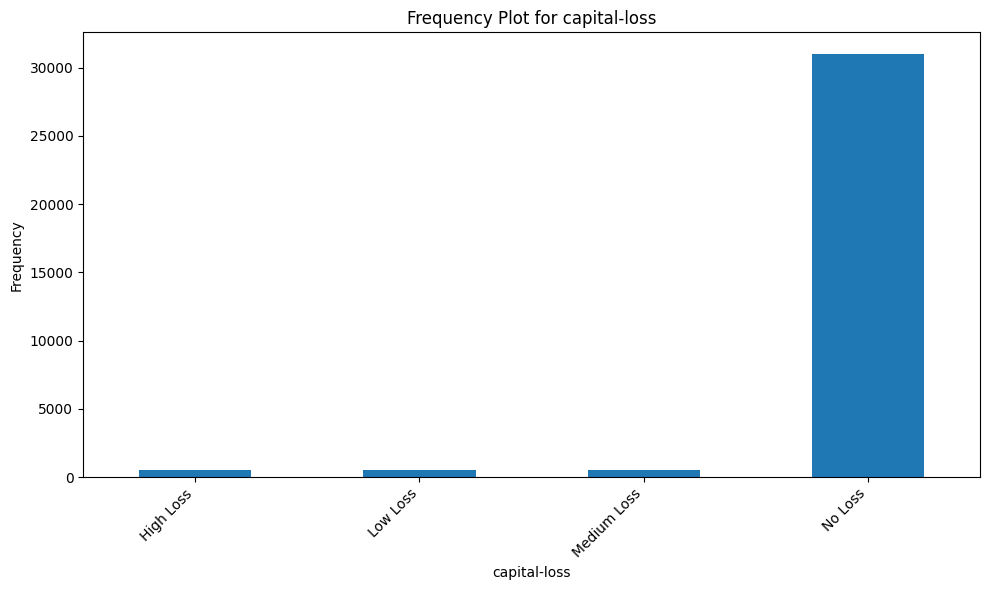

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['capital-loss'], 'capital-loss')

Hours-per-week

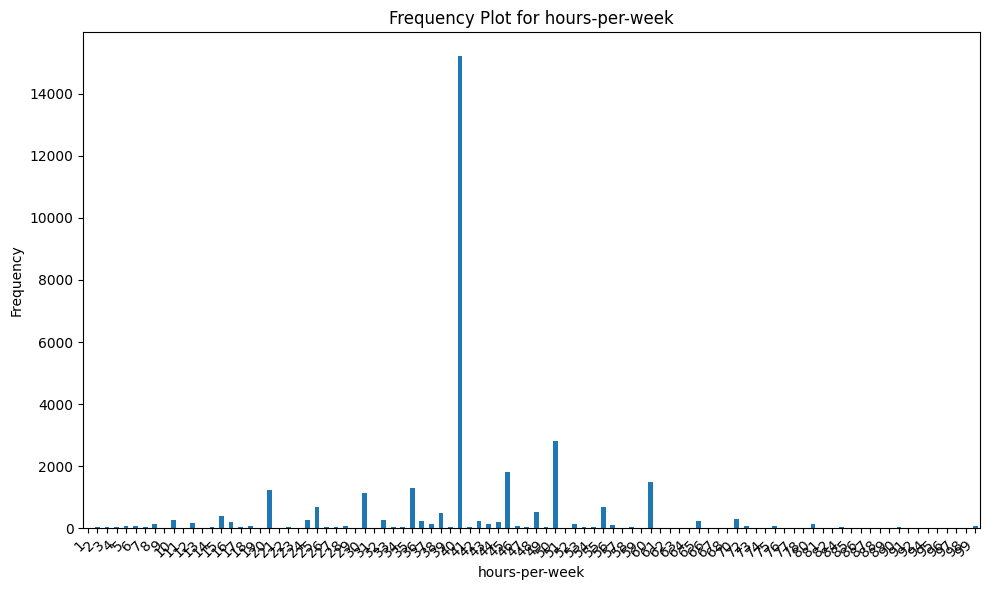

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['hours-per-week'], 'hours-per-week')

In [ ]:
adult_df_strategy_2['hours-per-week'] = pd.cut(adult_df_strategy_2['hours-per-week'], bins=5,
                                               labels = [
                                                   'Very Low Hours',
                                                   'Low Hours',
                                                   'Medium Hours',
                                                   'High Hours',
                                                   'Very High Hours'
                                               ])

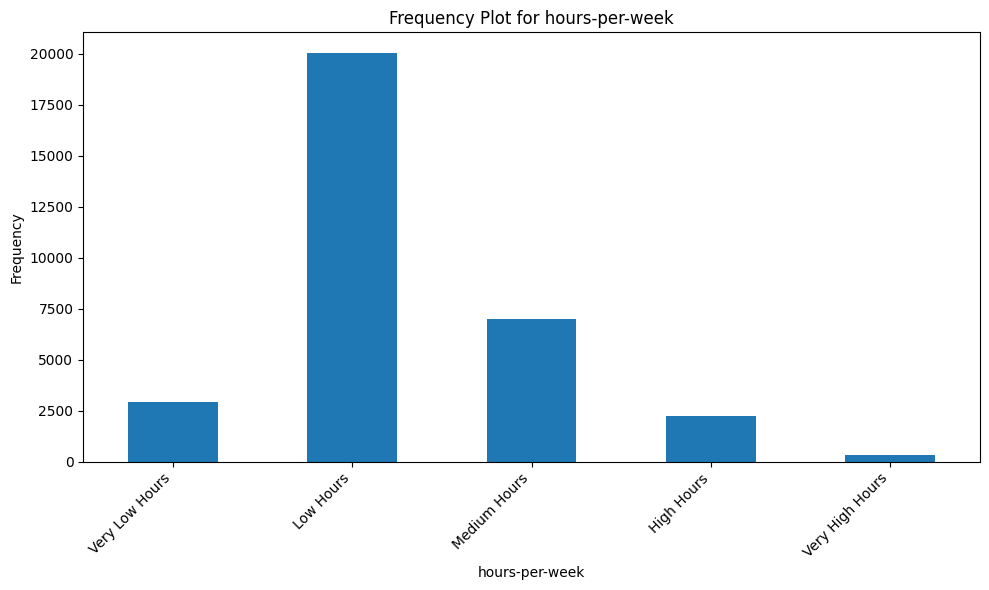

In [ ]:
plot_frequency_distribution(adult_df_strategy_2['hours-per-week'], 'hours-per-week')

Explanation of Why `qcut` struggled with `capital-gain`, `capital-loss`, and `hours-per-week`

`pd.qcut` performs **equal-frequency binning**, which means it divides the data into intervals so that each bin contains approximately the same number of observations. To achieve this, it determines bin boundaries using **quantiles**. However, variables such as `capital-gain`, `capital-loss`, and `hours-per-week` present difficulties for this approach because their distributions are **highly skewed** and contain a large concentration of repeated values, especially zeros.

In the case of `capital-gain` and `capital-loss`, around **92–95% of the observations are equal to zero**, which causes multiple quantiles to fall on the same value. As a result, `qcut` attempts to create bin edges that are not unique, producing the error **“Bin edges must be unique.”** Even when duplicate edges are removed using `duplicates='drop'`, the number of resulting bins may be smaller than expected, which can lead to mismatches between the number of bins and the provided labels. Because of this behavior, `qcut` is better suited for data with smoother distributions, while alternatives such as **`pd.cut` (equal-width binning)** or custom binning strategies are often more reliable for variables with extreme value concentrations.

#### Comparison

In [ ]:
def compare_column_distributions(column_name):
    fig, axes = plt.subplots(1, 3, figsize=(25, 6))
    fig.suptitle(f'Column: {column_name}', fontsize=16)

    # Original DataFrame (adult_df)
    ax1 = axes[0]
    if pd.api.types.is_numeric_dtype(adult_df[column_name]):
        sns.histplot(adult_df[column_name], kde=True, ax=ax1)
        ax1.set_title(f'Original (Histogram)')
    else:
        adult_df[column_name].value_counts().sort_index().plot(kind='bar', ax=ax1)
        ax1.set_title(f'Original (Frequency)')
    ax1.set_xlabel(column_name)
    ax1.set_ylabel('Frequency')
    # Rotate labels if they overlap
    ax1.tick_params(axis='x', rotation=45)
    plt.setp(ax1.get_xticklabels(), ha='right') # Set horizontal alignment for labels

    # Strategy 1 DataFrame (adult_df_strategy_1)
    ax2 = axes[1]
    adult_df_strategy_1[column_name].value_counts().sort_index().plot(kind='bar', ax=ax2)
    ax2.set_title(f'Strategy 1')
    ax2.set_xlabel(column_name)
    ax2.set_ylabel('Frequency')
    ax2.tick_params(axis='x', rotation=45)
    plt.setp(ax2.get_xticklabels(), ha='right')

    # Strategy 2 DataFrame (adult_df_strategy_2)
    ax3 = axes[2]
    adult_df_strategy_2[column_name].value_counts().sort_index().plot(kind='bar', ax=ax3)
    ax3.set_title(f'Estrategia 2 (Frecuencia Igual)')
    ax3.set_xlabel(column_name)
    ax3.set_ylabel('Frecuencia')
    ax3.tick_params(axis='x', rotation=45)
    plt.setp(ax3.get_xticklabels(), ha='right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

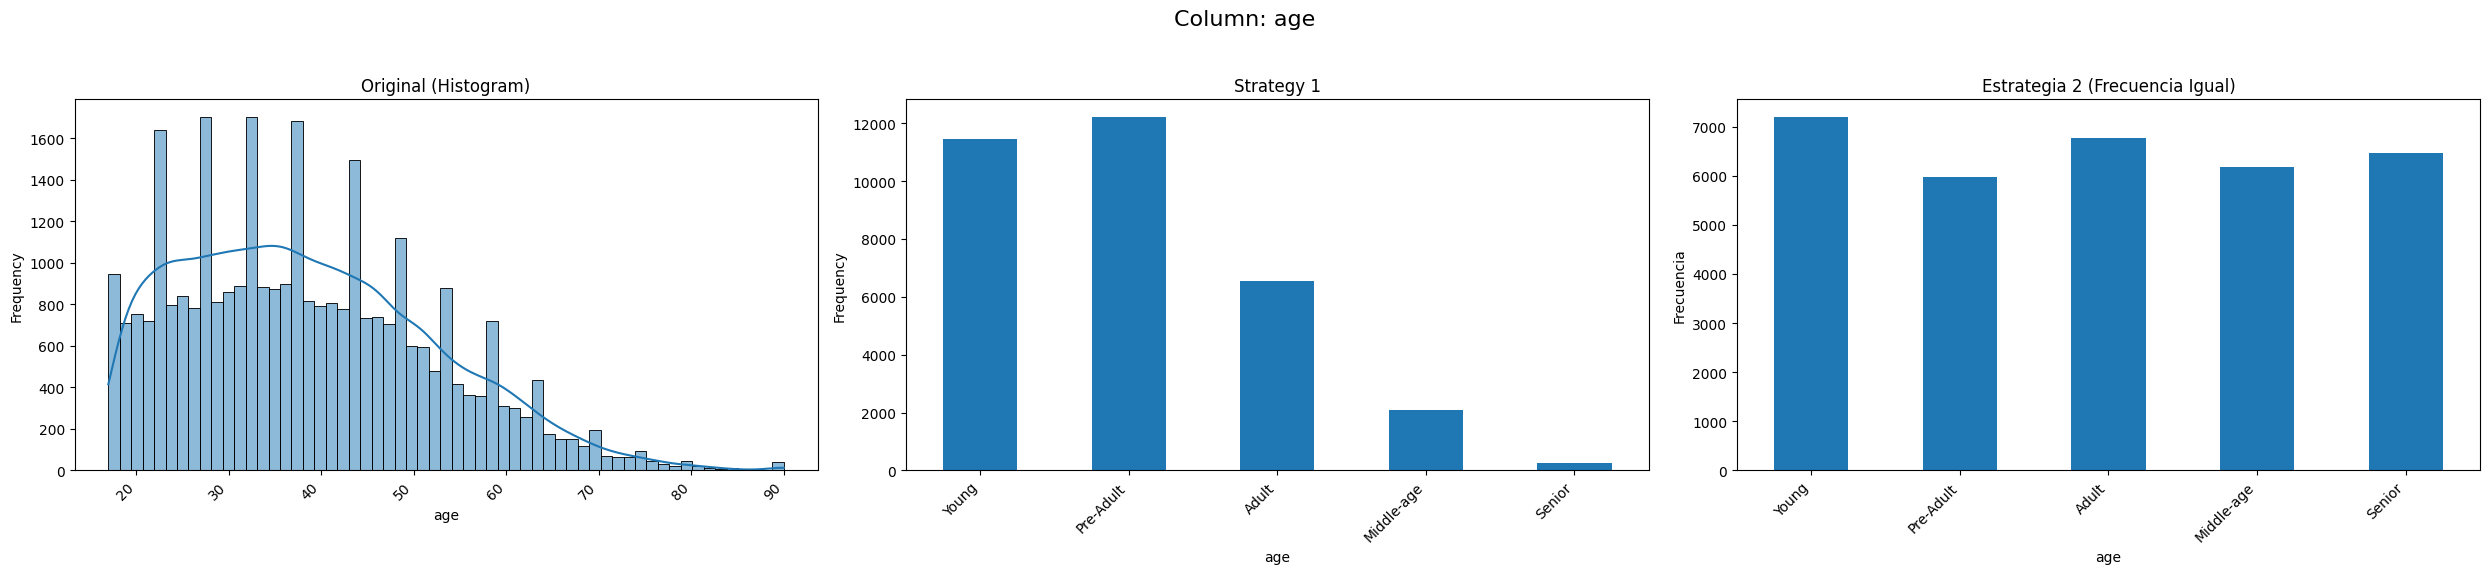

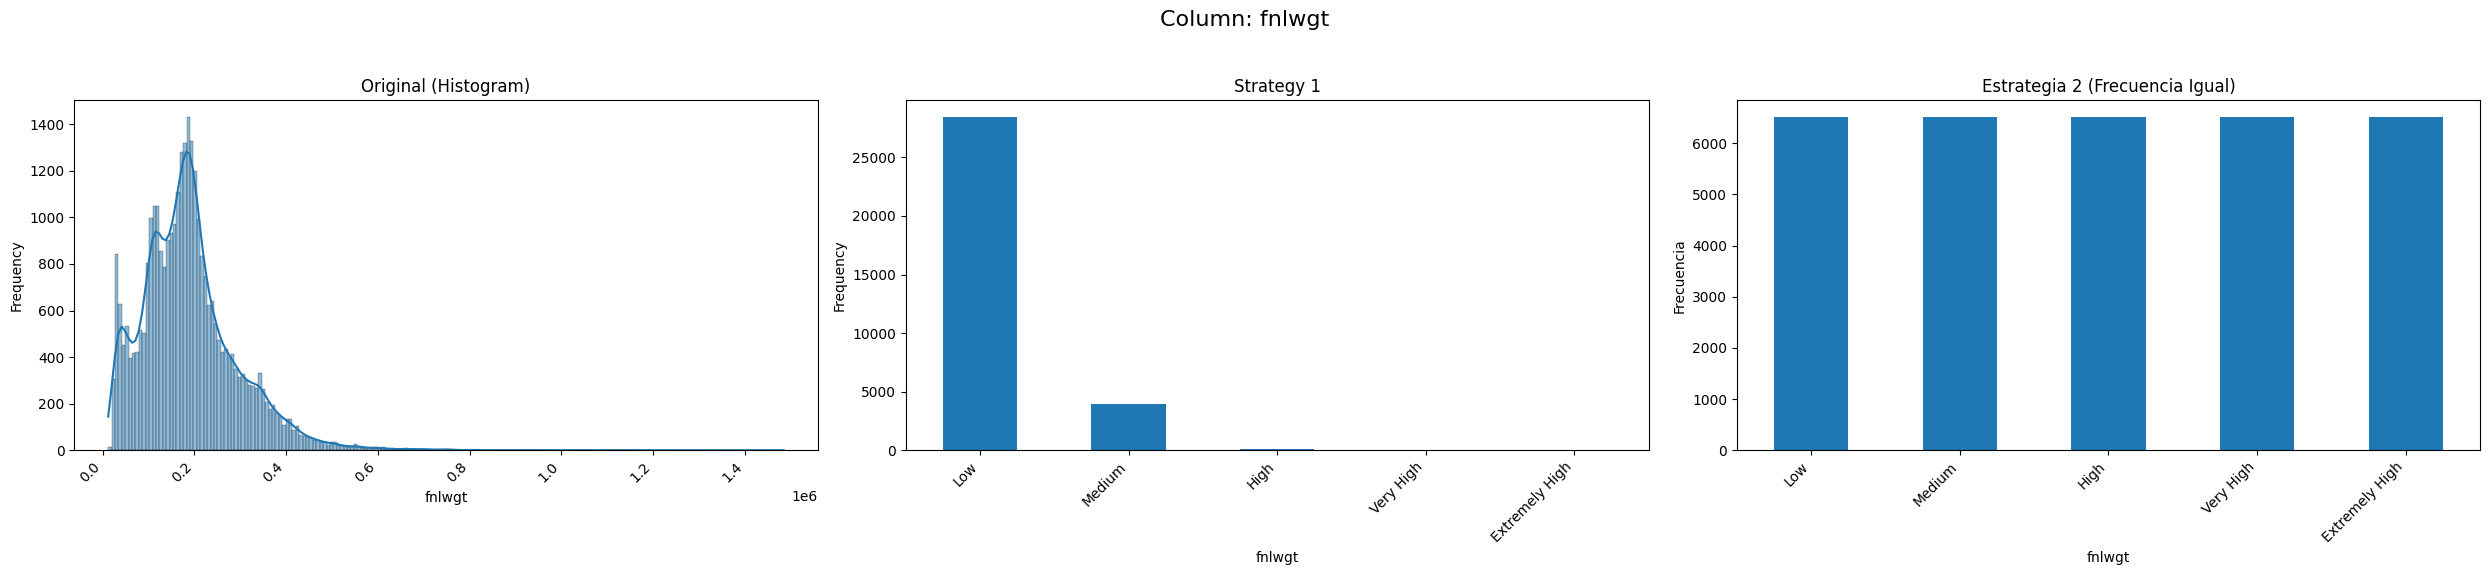

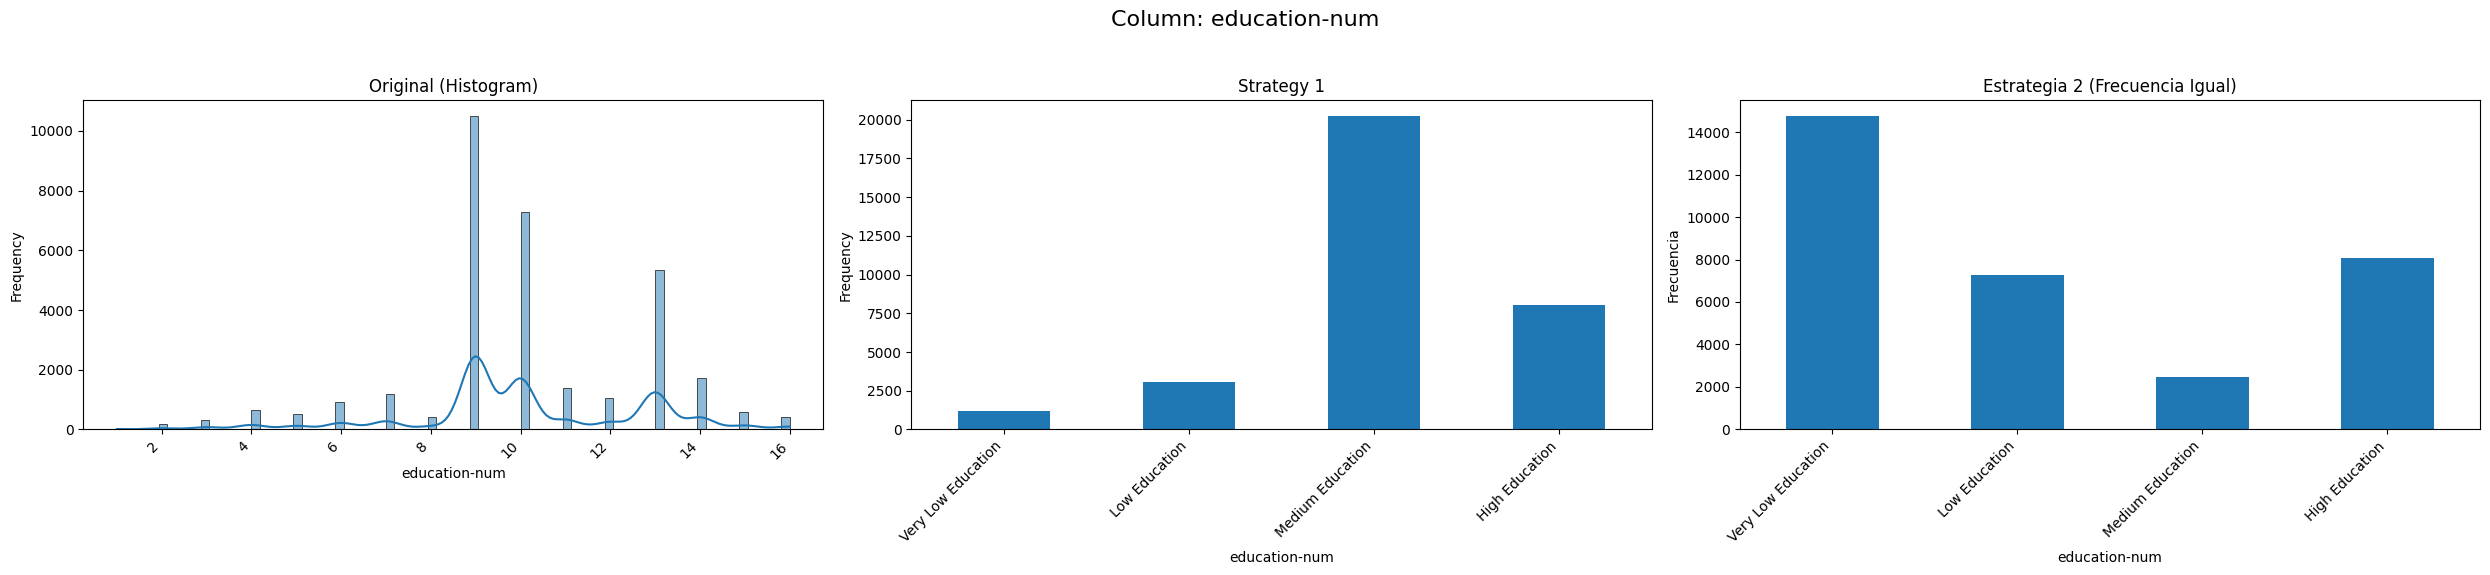

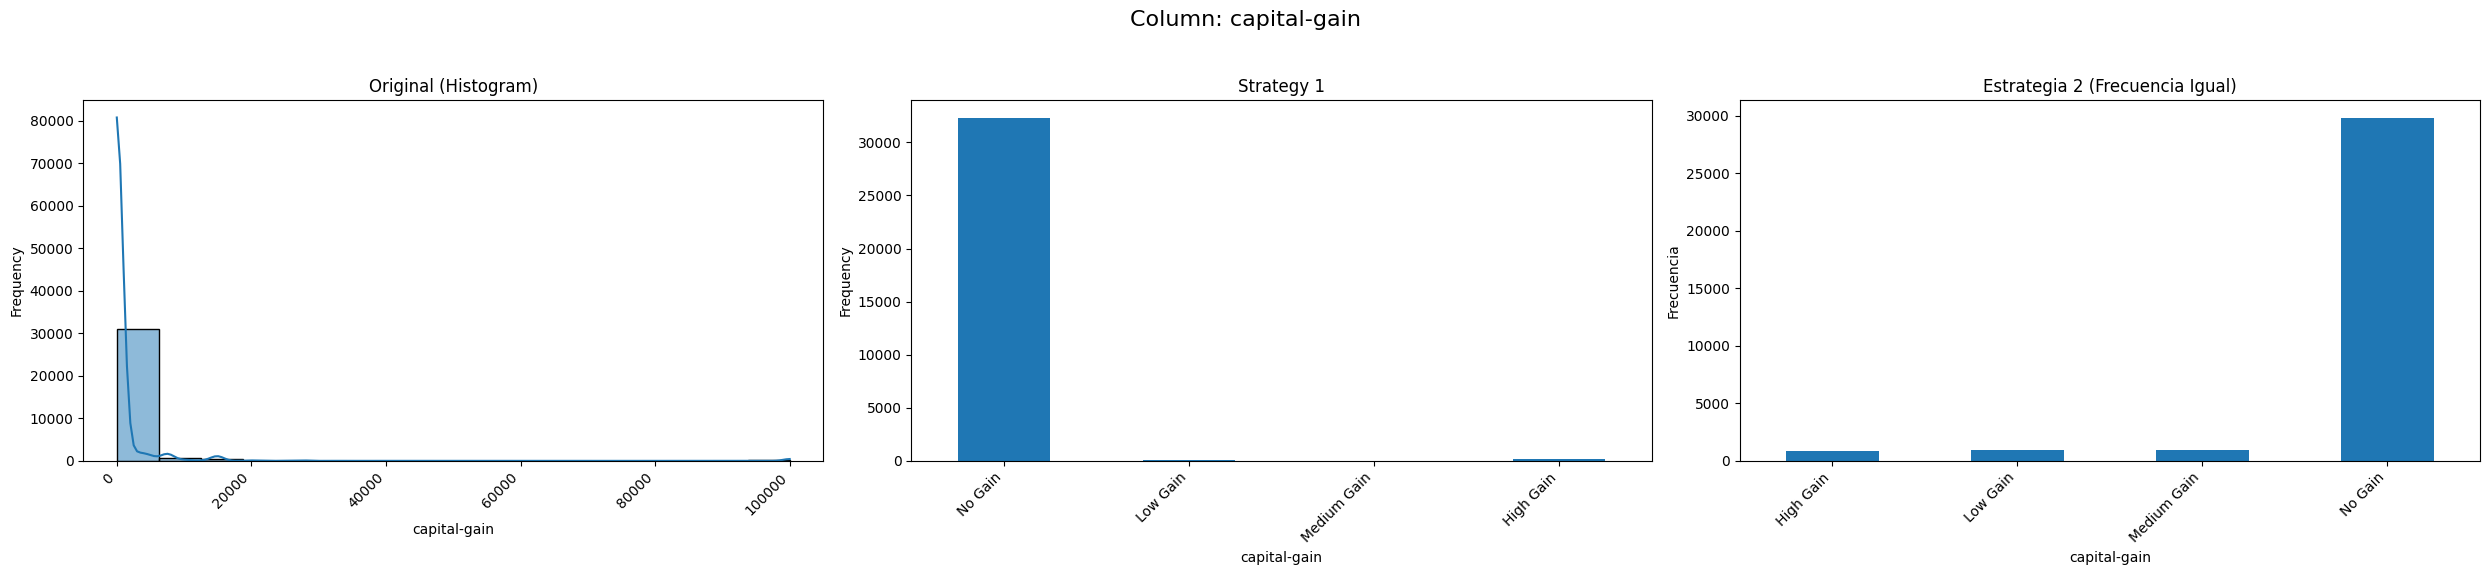

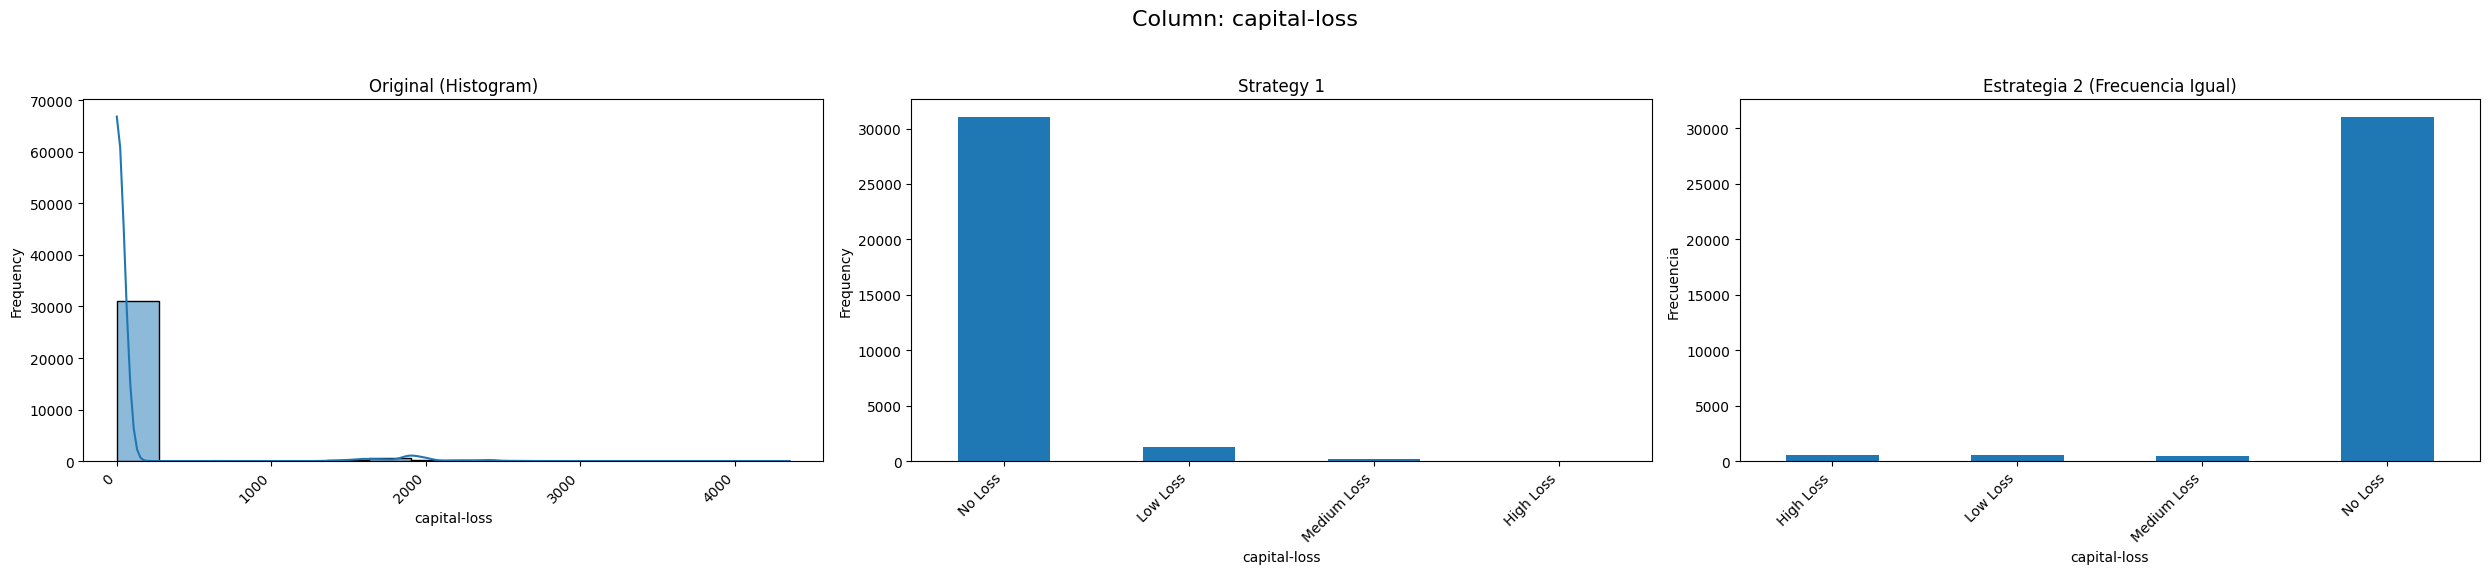

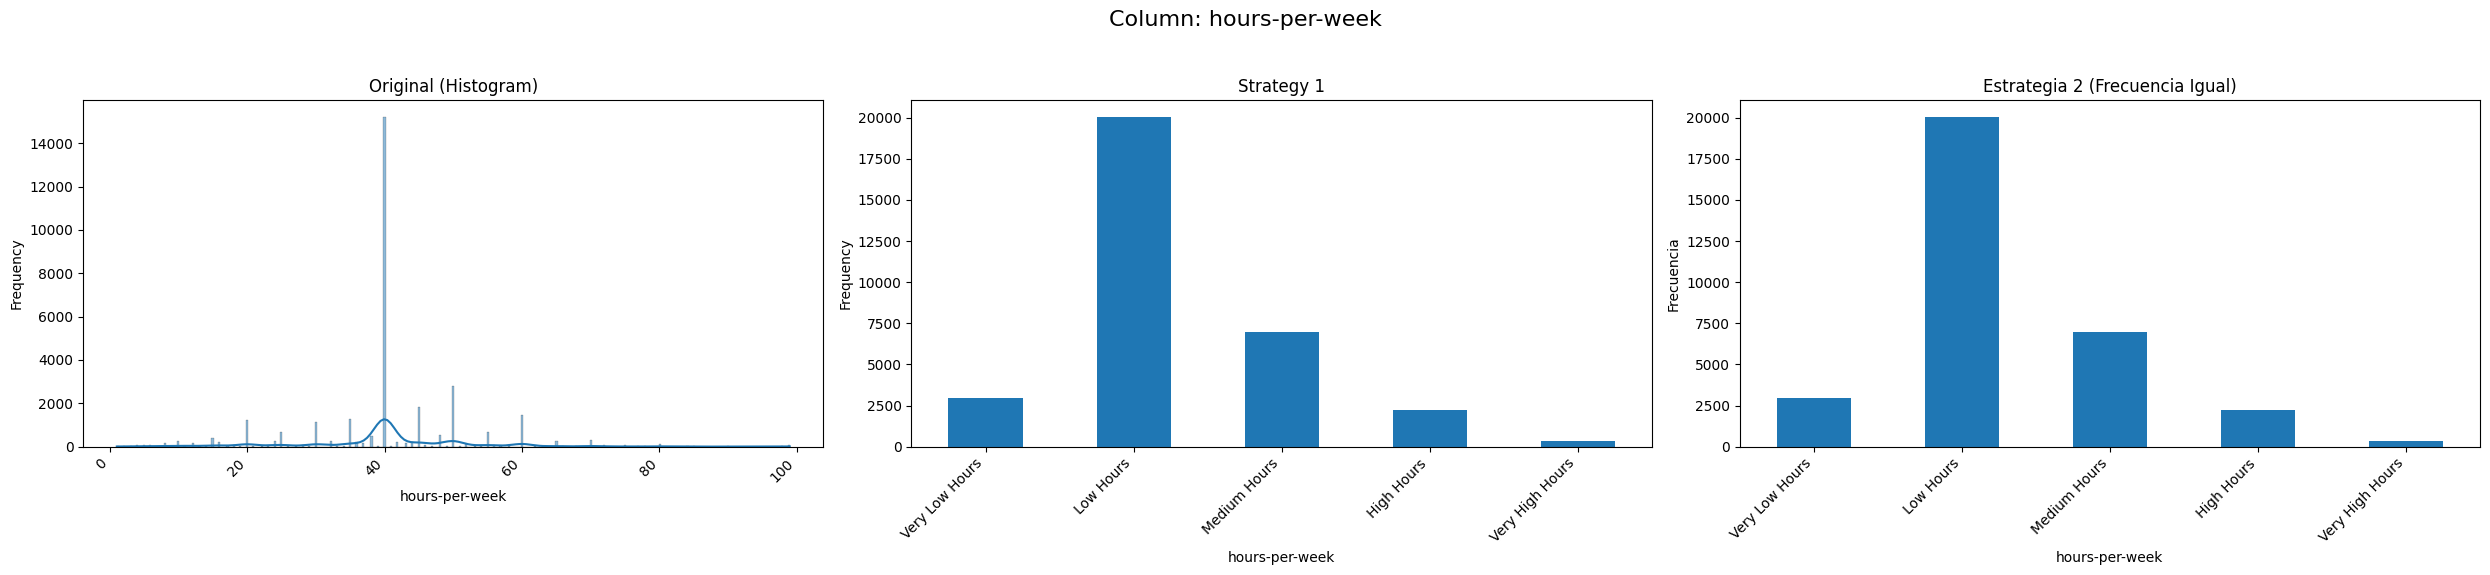

In [ ]:
for column in numerical_cols_adult_df:
    compare_column_distributions(column)

### **Every attribute is numerical**

After discretizing the numerical attributes, all variables in the dataset become categorical. Since many data mining and machine learning algorithms require **numerical input**, it is necessary to transform these categorical attributes into a numeric representation. This transformation is performed using encoding techniques that preserve the information contained in each category while allowing the dataset to be processed by computational models.

For **nominal attributes** (variables without an inherent order), such as `workclass`, `marital-status`, `education`,`occupation`, `relationship`, `race`, `sex`, and `native-country`, **One-Hot Encoding** is used. This method creates a binary column for each category, indicating the presence (1) or absence (0) of that category in each observation. One-hot encoding is appropriate for nominal variables because it avoids introducing artificial ordinal relationships between categories that are conceptually unordered.

For attributes that represent **ordered categories**, particularly those obtained through discretization (such as `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, and `hours-per-week` after binning), an **ordinal encoding strategy** is applied. In this approach, each category is mapped to an integer value that reflects its relative order (for example, from "Very Low" to "Very High"). This preserves the ordinal structure introduced during the discretization process while maintaining a fully numerical dataset.

By applying these encoding techniques, the entire dataset is transformed into a **numerical feature space**, ensuring compatibility with statistical analysis and machine learning algorithms while preserving the structural meaning of the original attributes.

In [ ]:
ordinal_columns = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
norminal_columns =  ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income', 'education']

In [ ]:
ordinal_categories = {'age':['Young', 'Pre-Adult', 'Adult', 'Middle-age', 'Senior'],
                      'fnlwgt':['Low',  'Medium', 'High', 'Very High', 'Extremely High'],
                      'education-num':["Very Low Education", "Low Education", "Medium Education", "High Education"],
                      'capital-gain':["No Gain", "Low Gain", "Medium Gain", "High Gain"],
                      'capital-loss':["No Loss", "Low Loss", "Medium Loss", "High Loss"],
                      'hours-per-week':['Very Low Hours', 'Low Hours', 'Medium Hours', 'High Hours', 'Very High Hours']
              }

#### Nominal Attributes

In [ ]:
def one_hot_encode_column(df, column_name):
    if column_name not in df.columns:
        print(f"Error: La columna '{column_name}' no se encuentra en el DataFrame.")
        return df

    one_hot_encoded = pd.get_dummies(df[column_name], prefix=column_name)
    df_encoded = pd.concat([df.drop(columns=[column_name]), one_hot_encoded], axis=1)
    return df_encoded

In [ ]:
for column in norminal_columns:
    adult_df_strategy_1 = one_hot_encode_column(adult_df_strategy_1, column)
    adult_df_strategy_2 = one_hot_encode_column(adult_df_strategy_2, column)

In [ ]:
adult_df_strategy_1.shape

(32561, 110)

#### Attributes that represent ordered categories

In [ ]:
def ordinal_encode_column(df, column_name, categories):
    if column_name not in df.columns:
        print(f"Error: La columna '{column_name}' no se encuentra en el DataFrame.")
        return df

    df[column_name] = pd.Categorical(df[column_name], categories=categories, ordered=True)
    df[column_name] = df[column_name].cat.codes

    return df

In [ ]:
for column in ordinal_columns:
    adult_df_strategy_1 = ordinal_encode_column(adult_df_strategy_1, column, ordinal_categories[column])
    adult_df_strategy_2 = ordinal_encode_column(adult_df_strategy_2, column, ordinal_categories[column])

#### Results

In [ ]:
display(adult_df_strategy_1.head())
adult_df_strategy_1.shape

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,education_ 9th,education_ Assoc-acdm,education_ Assoc-voc,education_ Bachelors,education_ Doctorate,education_ HS-grad,education_ Masters,education_ Preschool,education_ Prof-school,education_ Some-college
0,1,0,3,0,0,1,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,2,0,3,0,0,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,1,0,2,0,0,1,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,2,0,1,0,0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,1,3,0,0,1,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


(32561, 110)

In [ ]:
display(adult_df_strategy_2.head())
adult_df_strategy_2.shape

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,education_ 9th,education_ Assoc-acdm,education_ Assoc-voc,education_ Bachelors,education_ Doctorate,education_ HS-grad,education_ Masters,education_ Preschool,education_ Prof-school,education_ Some-college
0,2,0,3,1,0,1,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,3,0,3,0,0,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,2,3,0,0,0,1,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,3,0,0,0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,4,3,0,0,1,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


(32561, 110)

In [ ]:
print(f'Original Dataset Columns: {adult_df.columns}')
print(f'Final Dataset Columns: {adult_df_strategy_1.columns}')

Original Dataset Columns: Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')
Final Dataset Columns: Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov',
       'workclass_ Local-gov', 'workclass_ Never-worked',
       ...
       'education_ 9th', 'education_ Assoc-acdm', 'education_ Assoc-voc',
       'education_ Bachelors', 'education_ Doctorate', 'education_ HS-grad',
       'education_ Masters', 'education_ Preschool', 'education_ Prof-school',
       'education_ Some-college'],
      dtype='object', length=110)


## **9. Ranking de dimensiones (media y varianza)**

Dado el siguiente conjunto de datos con tres dimensiones de entrada y una dimensión de clase:

|I1|I2|I3|C|
|--|--|--|--|
|2.5 | 1.6 | 5.9 | 0 |
|2.5 | 1.6 | 5.9 | 0 |
|7.2 | 4.3 | 2.1 | 1 |
|3.4 | 5.8 | 1.6 | 1 |
|5.6 | 3.6 | 6.8 | 0 |
|4.8 | 7.2 | 3.1 | 1 |
|8.1 | 4.9 | 8.3 | 0 |
|6.3 | 4.8 | 2.4 | 1 |

Realizar el ranking de las dimensiones mediante comparación de medias y varianzas.

In [ ]:
df_9 = pd.DataFrame({
    'I1': [2.5, 2.5, 7.2, 3.4, 5.6, 4.8, 8.1, 6.3],
    'I2': [1.6, 1.6, 4.3, 5.8, 3.6, 7.2, 4.9, 4.8],
    'I3': [5.9, 5.9, 2.1, 1.6, 6.8, 3.1, 8.3, 2.4],
    'C': [0, 0, 1, 1, 0, 1, 0, 1]
})

In [ ]:
def SE(XA, XB):
    return np.sqrt(np.var(XA, ddof=1)/len(XA) + np.var(XB, ddof=1)/len(XB))

In [ ]:
def test(XA, XB, umbral=0.5):
    SE_AB = SE(XA, XB)
    t = np.abs(np.mean(XA) - np.mean(XB))
    return t/SE_AB, t/SE_AB > umbral

In [ ]:
def reduction_dimension(df, class_column, umbral = 0.5):
  rankings = []
  print(f'Reducing Dimension Using an umbral of {umbral}')

  # Get the unique classes
  classes = df[class_column].unique()
  if len(classes) != 2:
      print("This ranking method is designed for binary classification.")
      return
  class_0_data = df[df[class_column] == classes[0]]
  class_1_data = df[df[class_column] == classes[1]]

  for col_name in df.columns:
    if col_name == class_column:
      continue

    XA = class_0_data[col_name]
    XB = class_1_data[col_name]

    t_value, passes_umbral = test(XA, XB, umbral)
    rankings.append({'dimension': col_name, 't_value': t_value, 'passes_umbral': passes_umbral})

  # Sort by t_value in descending order (higher t_value means better separation)
  rankings_df = pd.DataFrame(rankings).sort_values(by='t_value', ascending=False).reset_index(drop=True)

  print("\nDimension Rankings (higher t_value indicates better separation):")
  ##Sort
  rankings_df = rankings_df.sort_values(by='t_value', ascending=False)
  display(rankings_df)
  if rankings_df.iloc[0]['passes_umbral']:
    reduced_df = df.drop(columns=[rankings_df['dimension'].iloc[0]])
  else:
    reduced_df = df
    print('Dataset cant be reduced because there are no attributes that pass the umbral')
  return reduced_df


In [ ]:
reduced_df = reduction_dimension(df_9, 'C', 2)

Reducing Dimension Using an umbral of 2

Dimension Rankings (higher t_value indicates better separation):


,dimension,t_value,passes_umbral
0,I3,6.836406,True
1,I2,2.519901,True
2,I1,0.470785,False


## **10. Selección de características usando entropía**

Dado el conjunto de datos:

|X1|X2|X3|X4|
|--|--|--|--|
|2.7 | 3.4 | 1 | A |
|3.1 | 6.2 | 2 | A |
|4.5 | 2.8 | 1 | B |
|5.3 | 5.8 | 2 | B |
|6.6 | 3.1 | 1 | A |
|5.0 | 4.1 | 2 | B |

Aplicar el método de selección de características basado en entropía para reducir una dimensión (mostrar pasos).

In [ ]:
df_10 = pd.DataFrame({
    'X1': [2.7, 3.1, 4.5, 5.3, 6.6, 5.0],
    'X2': [3.4, 6.2, 2.8, 5.8, 3.1, 4.1],
    'X3': [1, 2, 1, 2, 1, 2],
    'X4': ['A', 'A', 'B', 'B', 'A', 'B']
})
df_10

,X1,X2,X3,X4
0,2.7,3.4,1,A
1,3.1,6.2,2,A
2,4.5,2.8,1,B
3,5.3,5.8,2,B
4,6.6,3.1,1,A
5,5.0,4.1,2,B


In [ ]:
type_attributes = {'X1': 'numeric', 'X2': 'numeric', 'X3': 'nominal', 'X4': 'nominal'}

In [ ]:
def similarity_matrix(df, attribute_types):
    """
    Computes the similarity matrix between records.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the records.
    attribute_types : dict
        Dictionary specifying the type of each attribute:
        {'col1': 'nominal', 'col2': 'numeric', ...}

    Returns
    -------
    numpy.ndarray
        Similarity matrix (n x n)
    """

    num_records = len(df)
    num_attributes = len(df.columns)

    matrix = np.zeros((num_records, num_records))

    # Precompute ranges for numeric attributes (used to calculate alpha)
    ranges = {}
    for col in df.columns:
        if attribute_types[col] == 'numeric':
            ranges[col] = df[col].max() - df[col].min()
            if ranges[col] == 0:
                ranges[col] = 1  # avoid division by zero

    for i in range(num_records):
        for j in range(num_records):

            if i < j:
                similarity_sum = 0

                for col in df.columns:

                    xi = df.iloc[i][col]
                    xj = df.iloc[j][col]

                    if attribute_types[col] == 'nominal':
                        # Hamming similarity
                        s = 1 if xi == xj else 0

                    else:
                        # Numeric attribute similarity
                        D = abs(xi - xj)

                        alpha = -np.log(0.5) / ranges[col]

                        s = np.exp(-alpha * D)

                    similarity_sum += s

                matrix[i][j] = similarity_sum / num_attributes
                matrix[j][i] = matrix[i][j]  # symmetric matrix

    return matrix

In [ ]:
def entropy(similarity_matrix):
    # print('Similarity matrix used in entropy calculation:', similarity_matri
    entropy_value = 0
    for row in similarity_matrix:
        for value in row:
            if value > 0:
                entropy_value -= (value * np.log10(value)) + ((1 - value) * np.log10(1 - value))

    # Check if entropy is NaN and return negative infinity in that case
    if np.isnan(entropy_value):
        # print("Computed entropy: -inf (NaN detected)")
        return -np.inf

    # print(f"Computed entropy: {entropy_value}")
    return entropy_value

In [ ]:
def delete_attribute(index, df):
    """
    Removes an attribute (column) from a pandas DataFrame by index.

    Parameters
    ----------
    index : int
        Index of the attribute to remove.
    df : pandas.DataFrame
        DataFrame containing the records.

    Returns
    -------
    pandas.DataFrame
        Modified DataFrame without the selected attribute.
    """

    columns = df.columns.tolist()

    if index < 0 or index >= len(columns):
        print("    Index out of range. No attribute will be removed.")
        return df

    column_name = columns[index]

    print(f"    → Removing attribute {column_name}...")

    modified_df = df.drop(columns=[column_name])

    return modified_df

In [ ]:
def calculate_attribute_to_delete(df, attribute_types):
    """
    Determines which attribute should be removed based on entropy reduction.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing the records.
    attribute_types : dict
        Dictionary specifying the type of each attribute
        {'col1': 'nominal', 'col2': 'numeric', ...}

    Returns
    -------
    str
        Name of the attribute that should be removed.
    """

    attributes = df.columns.tolist()
    num_attributes = len(attributes)

    # Compute entropy of the original dataset
    original_similarity = similarity_matrix(df, attribute_types)
    original_entropy = entropy(original_similarity)

    print(f'Original Entropy: {original_entropy}')

    entropy_list = []

    for column_name in attributes:

        print(f"    → Testing removal of attribute {column_name}...")

        # Create a modified dataset without the column
        modified_df = df.drop(columns=[column_name])

        # Update attribute types
        modified_types = {k: v for k, v in attribute_types.items() if k != column_name}

        # Recompute similarity and entropy
        matrix = similarity_matrix(modified_df, modified_types)
        current_entropy = entropy(matrix)

        entropy_difference = np.abs(original_entropy - current_entropy)

        print(
            f"    → Entropy after removing {column_name}: {current_entropy}, "
            f"Entropy reduction: {entropy_difference}\n"
        )

        entropy_list.append((column_name, entropy_difference))

    # Sort attributes by entropy reduction (ascending)
    entropy_list.sort(key=lambda x: x[1])

    ordered_attributes = [attr for attr, _ in entropy_list]

    print(f"    → Variable Ranking: {ordered_attributes}")

    return ordered_attributes[0]

In [ ]:
def dimensionality_reduction(df, attribute_types):
    """
    Performs entropy-based dimensionality reduction by iteratively
    removing the least relevant attribute.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing the records.
    attribute_types : dict
        Dictionary specifying the type of each attribute
        {'col1': 'nominal', 'col2': 'numeric', ...}

    Returns
    -------
    pandas.DataFrame
        DataFrame with the remaining attributes.
    list
        List of removed attributes in the order they were eliminated.
    """

    df_iteration = df.copy()
    ranking = []

    print(f"Initial dataset:\n{df_iteration}")
    print(f"Initial variables: {df_iteration.columns.tolist()}")

    num_attributes = len(df_iteration.columns)

    for i in range(num_attributes - 1):

        print(f"\nIteration {i+1}:")

        # Determine which attribute should be removed
        attribute_to_remove = calculate_attribute_to_delete(df_iteration, attribute_types)

        # Remove the attribute from the dataset
        df_iteration = df_iteration.drop(columns=[attribute_to_remove])

        # Save the ranking
        ranking.append(attribute_to_remove)

        # Update attribute types
        attribute_types = {k: v for k, v in attribute_types.items() if k != attribute_to_remove}

        print(f"    Result after iteration {i+1}:")
        print(df_iteration)

    print(f"\nAttributes removed in order: {ranking}")

    return df_iteration, ranking

In [ ]:
reduced_df_10, ranking_df_10 = dimensionality_reduction(df_10, type_attributes)

Initial dataset:
    X1   X2  X3 X4
0  2.7  3.4   1  A
1  3.1  6.2   2  A
2  4.5  2.8   1  B
3  5.3  5.8   2  B
4  6.6  3.1   1  A
5  5.0  4.1   2  B
Initial variables: ['X1', 'X2', 'X3', 'X4']

Iteration 1:
Original Entropy: 7.987291800597772
    → Testing removal of attribute X1...
    → Entropy after removing X1: 7.344053705325474, Entropy reduction: 0.6432380952722978

    → Testing removal of attribute X2...
    → Entropy after removing X2: 7.54983308795213, Entropy reduction: 0.4374587126456424

    → Testing removal of attribute X3...
    → Entropy after removing X3: 7.763971707313381, Entropy reduction: 0.22332009328439106

    → Testing removal of attribute X4...
    → Entropy after removing X4: 7.525494186117496, Entropy reduction: 0.46179761448027623

    → Variable Ranking: ['X3', 'X2', 'X4', 'X1']
    Result after iteration 1:
    X1   X2 X4
0  2.7  3.4  A
1  3.1  6.2  A
2  4.5  2.8  B
3  5.3  5.8  B
4  6.6  3.1  A
5  5.0  4.1  B

Iteration 2:
Original Entropy: 7.763971707

## **11. PCA (Principal Component Analysis)**
El análisis de componentes principales (ACP) es un método clásico para reducir el número de atributos en los datos mediante la proyección de estos desde su espacio original de alta dimensión a un espacio de menor dimensión. Los nuevos atributos (también conocidos como componentes)  tienen las siguientes propiedades:




*   (1) son combinaciones lineales de los atributos originales,
*   (2) son ortogonales (perpendiculares) entre sí y
*   (3) capturan la máxima variación en los datos.

El siguiente ejemplo ilustra la aplicación de PCA a un conjunto de datos de imágenes. Hay 16 archivos RGB, cada uno con un tamaño de 111 x 111 píxeles. El código de ejemplo a continuación leerá cada archivo de imagen y convertirá la imagen RGB en una matriz de 111 x 111 x 3 = 36963 valores de características. Esto creará una matriz de datos de 16 x 36963. (ejemplo tomado de tutorial del libro de  "Introduction to Data Mining"


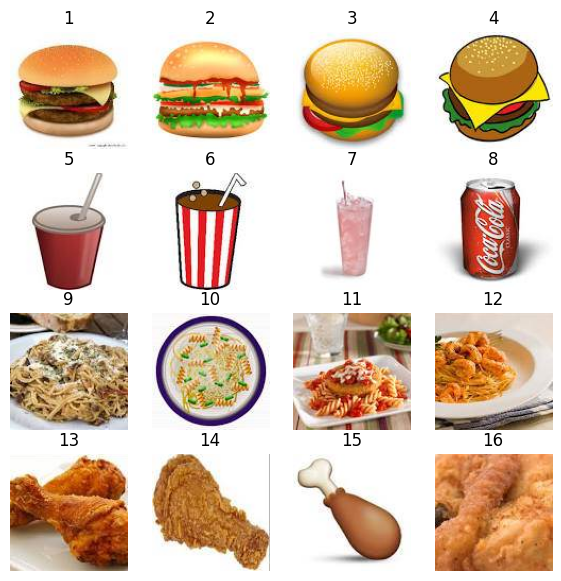

In [ ]:
%matplotlib inline

numImages = 16
fig = plt.figure(figsize=(7,7))
imgData = np.zeros(shape=(numImages,36963))

for i in range(1,numImages+1):
    filename = 'pics/Picture'+str(i)+'.jpg'
    img = mpimg.imread(filename)
    ax = fig.add_subplot(4,4,i)
    plt.imshow(img)
    plt.axis('off')
    ax.set_title(str(i))
    imgData[i-1] = np.array(img.flatten()).reshape(1,img.shape[0]*img.shape[1]*img.shape[2])

Usando PCA, la matrix de datos es proyectada a 2 componentes.

In [ ]:
numComponents = 2
pca = PCA(n_components=numComponents)
pca.fit(imgData)

projected = pca.transform(imgData)
projected = pd.DataFrame(projected,columns=['pc1','pc2'],index=range(1,numImages+1))
projected['food'] = ['burger', 'burger','burger','burger','drink','drink','drink','drink',
                      'pasta', 'pasta', 'pasta', 'pasta', 'chicken', 'chicken', 'chicken', 'chicken']
projected

,pc1,pc2,food
1,1592.934765,-6652.465553,burger
2,513.016263,-6333.802617,burger
3,-963.271943,-7208.765030,burger
4,-2165.163979,-9037.620490,burger
5,7842.507014,1063.686590,drink
6,8458.905775,5385.845816,drink
7,11181.706980,5360.954038,drink
8,6831.044934,-1130.402272,drink
9,-7639.829255,5059.445719,pasta
10,704.528728,530.699804,pasta


Finalmente, Dibujamos  scatter plot para ver los valores proyectados. Observe que las imágenes de hamburguesas, bebidas y pasta son proyectadas en la misma región. Sin embargo, Las imagenes de pollo frito es díficil de discriminar.

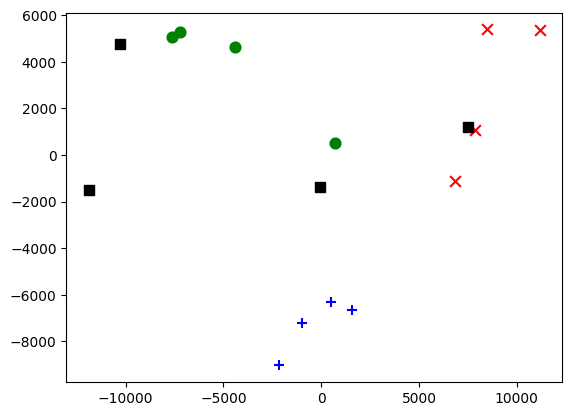

In [ ]:
import matplotlib.pyplot as plt

colors = {'burger':'b', 'drink':'r', 'pasta':'g', 'chicken':'k'}
markerTypes = {'burger':'+', 'drink':'x', 'pasta':'o', 'chicken':'s'}

for foodType in markerTypes:
    d = projected[projected['food']==foodType]
    plt.scatter(d['pc1'],d['pc2'],c=colors[foodType],s=60,marker=markerTypes[foodType])

Escoger un conjunto de datos del repositorio de Machine Learning que tenga varias dimensiones numéricas y aplicar ***PCA***. Describir el nuevo conjunto de datos.

### **Import Dataset Choosen from Machine Learning Repository - Predict Students' Dropout and Academic Success**

Download the dataset file through the following link:
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

Upload the file data.csv to this Notebook to be able to execute the following code blocks.

In [ ]:
students_df = pd.read_csv('/content/data.csv', sep=';')

In [ ]:
students_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [ ]:
students_df.shape

(4424, 37)

In [ ]:
print(students_df.dtypes)

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

### **Apply PCA to Students Dataset**

In [ ]:
students_n_final_components = 3
pca_students = PCA(n_components=students_n_final_components)

students_target = students_df['Target']
students_df = students_df.drop(columns=['Target'])
pca_students.fit(students_df)


projected_students = pca_students.transform(students_df)
projected_students = pd.DataFrame(projected_students,
                                  columns=[f'pc{i+1}' for i in range(students_n_final_components)],
                                  index=students_df.index)
projected_students['Target'] = students_target
students_df['Target'] = students_target

In [ ]:
students_target.value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [ ]:
projected_students.head()

,pc1,pc2,pc3,Target
0,-8685.660818,-0.854637,1.437229,Dropout
1,397.309320,-13.769327,-28.970813,Graduate
2,213.334821,-2.056054,8.574288,Dropout
3,916.379443,-9.016603,18.079181,Graduate
4,-842.606493,-0.128871,36.380282,Graduate


### **Plot Results of PCA**

In [ ]:
def plot_pca_projection(df, n_components, target_col, explained_variance_ratio):
    unique_targets = df[target_col].unique()
    colors = plt.cm.get_cmap('viridis', len(unique_targets))
    target_map = {target: i for i, target in enumerate(unique_targets)}

    # Define marker types for up to 3 classes (Dropout, Graduate, Enrolled)
    # If there are more classes, markers will cycle or need more explicit definition
    base_markers = ['o', 's', '^', 'D', 'p', 'h']
    marker_types = {target: base_markers[i % len(base_markers)] for i, target in enumerate(unique_targets)}

    # Add explained variance to labels
    pc1_var = explained_variance_ratio[0] * 100
    pc2_var = explained_variance_ratio[1] * 100 if n_components >= 2 and len(explained_variance_ratio) > 1 else 0
    pc3_var = explained_variance_ratio[2] * 100 if n_components >= 3 and len(explained_variance_ratio) > 2 else 0


    if n_components == 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.set_title('3D PCA Projection of Students Data')
        ax.set_xlabel(f'Principal Component 1 ({pc1_var:.2f}%)')
        ax.set_ylabel(f'Principal Component 2 ({pc2_var:.2f}%)')
        ax.set_zlabel(f'Principal Component 3 ({pc3_var:.2f}%)')

        for target in unique_targets:
            subset = df[df[target_col] == target]
            ax.scatter(subset['pc1'], subset['pc2'], subset['pc3'],
                       c=[colors(target_map[target])], marker=marker_types[target], label=target, s=50, alpha=0.7)
        ax.legend()

    elif n_components == 2:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111)
        ax.set_title('2D PCA Projection of Students Data')
        ax.set_xlabel(f'Principal Component 1 ({pc1_var:.2f}%)')
        ax.set_ylabel(f'Principal Component 2 ({pc2_var:.2f}%)')

        for target in unique_targets:
            subset = df[df[target_col] == target]
            ax.scatter(subset['pc1'], subset['pc2'],
                       c=[colors(target_map[target])], marker=marker_types[target], label=target, s=50, alpha=0.7)
        ax.legend()

    elif n_components == 1:
        fig = plt.figure(figsize=(10, 2))
        ax = fig.add_subplot(111)
        ax.set_title('1D PCA Projection of Students Data')
        ax.set_xlabel(f'Principal Component 1 ({pc1_var:.2f}%)')
        ax.set_yticks([])

        for target in unique_targets:
            subset = df[df[target_col] == target]
            ax.scatter(subset['pc1'], np.zeros_like(subset['pc1']),
                       c=[colors(target_map[target])], marker=marker_types[target], label=target, s=50, alpha=0.7)
        ax.legend()

    else:
        print("Please specify n_components as either 1, 2 or 3 for plotting.")
        return

    plt.grid(True)
    plt.show()

Plotting 3D PCA projection:


/tmp/ipykernel_619/20839820.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_targets))


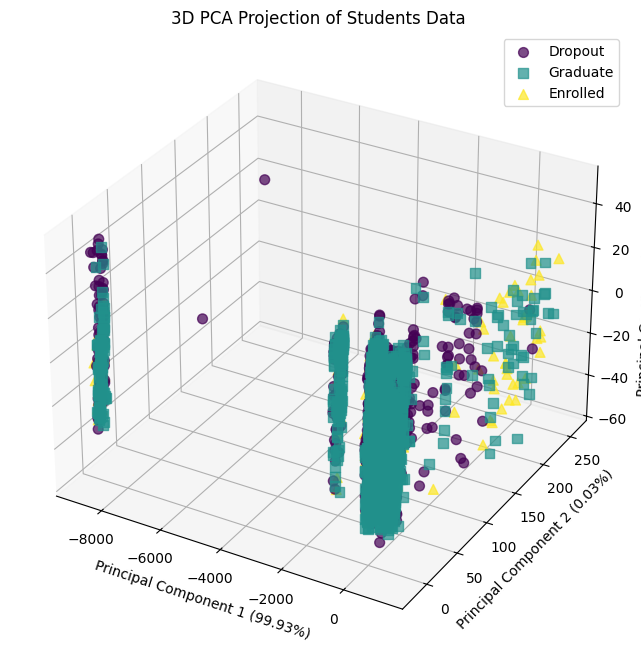


Plotting 2D PCA projection:


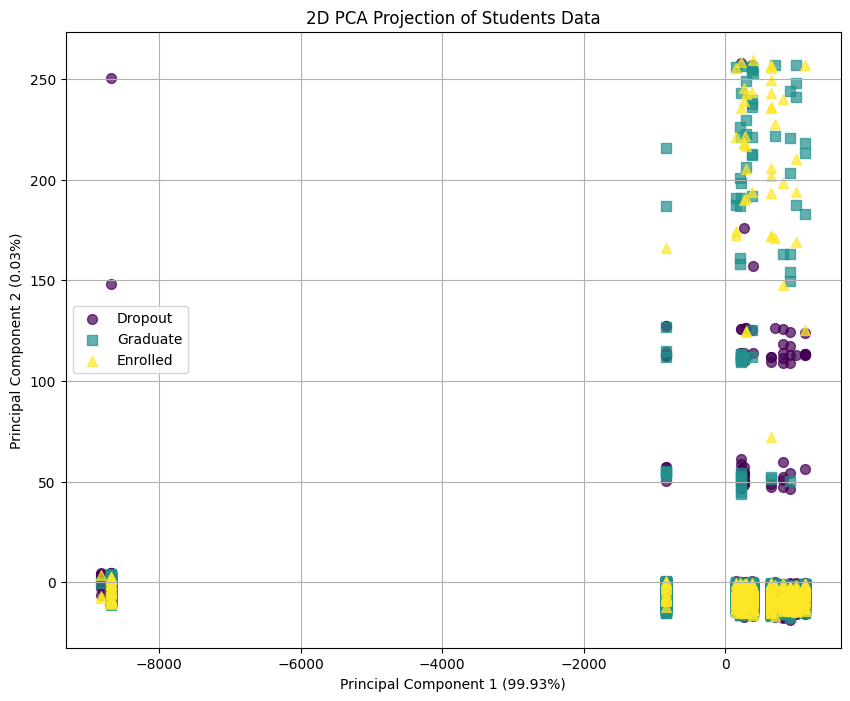


Plotting 1D PCA projection:


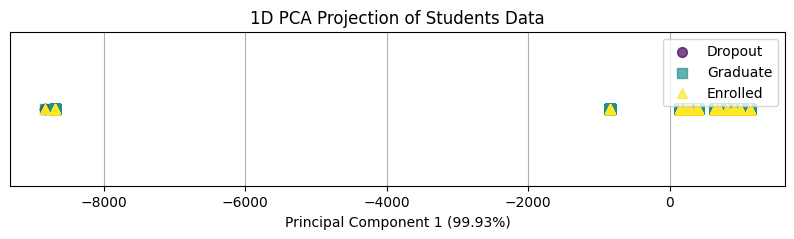

In [ ]:
if students_n_final_components >= 3:
    print("Plotting 3D PCA projection:")
    plot_pca_projection(projected_students, 3, 'Target', pca_students.explained_variance_ratio_)

if students_n_final_components >= 2:
    print("\nPlotting 2D PCA projection:")
    plot_pca_projection(projected_students, 2, 'Target', pca_students.explained_variance_ratio_)

if students_n_final_components >= 1:
    print("\nPlotting 1D PCA projection:")
    plot_pca_projection(projected_students, 1, 'Target', pca_students.explained_variance_ratio_)

/tmp/ipykernel_619/1309793428.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Principal Component', y='Explained Variance Ratio', data=pca_variance_df, marker='o', palette='viridis')


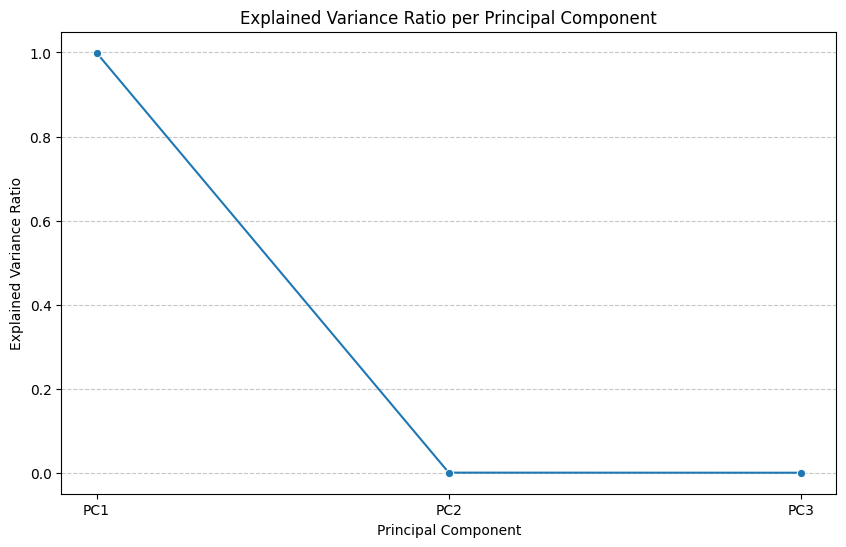

In [ ]:
# Get explained variance ratio
explained_variance_ratio = pca_students.explained_variance_ratio_

# Create a DataFrame for easier plotting
pca_variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Explained Variance Ratio': explained_variance_ratio
})

plt.figure(figsize=(10, 6))
sns.lineplot(x='Principal Component', y='Explained Variance Ratio', data=pca_variance_df, marker='o', palette='viridis')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Analysis PCA Columns Description and Conclusion**

**Principal Component Analysis (PCA) Transformation**

To reduce the dimensionality of the dataset while preserving as much information as possible, **Principal Component Analysis (PCA)** was applied using the implementation available in `sklearn.decomposition`.

First, the target variable was separated from the dataset since PCA must be applied only to the feature variables. The model was configured to compute **three principal components**, which means the original feature space is projected into a new space defined by three orthogonal directions that capture the maximum variance in the data.

```python
students_n_final_components = 3
pca_students = PCA(n_components=students_n_final_components)

students_target = students_df['Target']
students_df = students_df.drop(columns=['Target'])

pca_students.fit(students_df)
```

After fitting the PCA model, the dataset was transformed into the new component space:

```python
projected_students = pca_students.transform(students_df)

projected_students = pd.DataFrame(
    projected_students,
    columns=[f'pc{i+1}' for i in range(students_n_final_components)],
    index=students_df.index
)

projected_students['Target'] = students_target
students_df['Target'] = students_target
```

The resulting dataset contains the new attributes **PC1, PC2, and PC3**, which correspond to the principal components obtained from the linear combinations of the original variables.

---

**Explained Variance of the Components**

The explained variance ratio obtained from PCA was:

- **PC1:** 0.99933469 (≈ 99.93%)
- **PC2:** 0.00030032 (≈ 0.03%)
- **PC3:** 0.00009481 (≈ 0.009%)

This indicates that **almost all the variability of the dataset is captured by the first principal component**. The remaining components contribute only a negligible amount of additional information.

---

**Interpretation**

This behavior suggests that the numerical variables in the dataset are **highly correlated or follow a dominant underlying structure**, allowing the first principal component to summarize almost all the variability present in the original features.

Consequently:

- The dimensionality reduction achieved by PCA is extremely efficient.
- The dataset could potentially be represented using **only one principal component** while preserving more than **99% of the original variance**.
- The additional components mainly capture minor variations or noise in the data.

---

**Structure of the Transformed Dataset**

The transformed dataset now has the following structure:

| PC1 | PC2 | PC3 | Target |
|-----|-----|-----|--------|
| value | value | value | class |

Each row represents the projection of a student record onto the principal component space, while the **Target** variable is preserved for later analysis or predictive modeling.

---

**Limitations of variance-based interpretation in PCA**

Although the explained variance analysis shows that approximately **99.93% of the variance is captured by PC1**, this does not necessarily result in a clear or useful representation of the data for classification purposes. When the dataset is visualized or interpreted using only one principal component, the distribution of the classes appears confusing and difficult to distinguish.

---

**Why variance is not enough**

This behavior can be explained by the fact that PCA is an unsupervised technique. It does not take the target variable into account when generating the components, but instead focuses on maximizing variance. Consequently, the direction that captures the most variance (PC1) is not necessarily the one that best separates the classes. In this case, PC1 captures general variability in the data, but not the information that differentiates one class from another.

When analyzing the projections:

- Using only **PC1**, the classes show a significant overlap.
- Even when using **PC1 and PC2**, the separation between classes remains unclear.

This confirms that, despite preserving most of the variance, the **structure required for classification is not properly represented** in the first components.


For this reason, relying solely on explained variance to determine the number of components is not sufficient. Even though PCA suggests that one component could be enough, it becomes necessary to consider additional components or complementary techniques to retain the relevant information for classification tasks.

---

**Conclusion**

In this scenario, it can be concluded that **a high explained variance does not guarantee good class separability**. Therefore, it is important to complement PCA with other approaches that consider the relationship between the features and the target variable.